# **Assignment 04: CLIP**

**Available:** Sep 9, 2025 until Sep 18, 2025 11:59pm

## Tasks:
1. Train on Human Action Recognition (HAR) https://www.kaggle.com/shashankrapolu/datasets/human-Links 
 - Same train/test split

2. Fine Tune on HAR and compare CLIP, A-CLIP and SGLIP

3. Report performance, speed and memory consumption
    - SGLIP is able to load a very large batch size, use 32K
    - For CLIP, A-CLIP, use batch size of 4096

4. Include report, code and video to be submitted


## **Import Packages and Setup**

In [1]:
## Import Libraries

# Set CUDA_VISIBLE_DEVICES to make both GPUs visible
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

# Install all packages for from the requirements.txt
%pip install -r requirements.txt

import torch
import torch.nn as nn
import torchvision
import cv2
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch import optim
from tqdm.notebook import tqdm
from torchinfo import summary
import einops
import PIL
import numpy as np
import pandas as pd
# Use a pipeline as a high-level helper
from transformers import pipeline
import time
import psutil
import gc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from collections import defaultdict
import numpy as np

# Authorize Huggingface account
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv('/mnt/Storage02/SoftwareDev/CAP_6411_Assignments/.env')

# Get Hugging Face token
hf_token = os.getenv('HUGGINGFACE_HUB_TOKEN') or os.getenv('HF_TOKEN')

if hf_token:
    print("Found Hugging Face token in environment variables")
    
    
    from huggingface_hub import login, whoami
    
    try:
        # Login to Hugging Face Hub
        login(token=hf_token)
        
        # Verify login by getting user info
        user_info = whoami()
        print(f"Successfully authenticated with Hugging Face!")
        print(f"Logged in as: {user_info['name']}")
        
        # Set the token as environment variable for other libraries
        os.environ['HUGGINGFACE_HUB_TOKEN'] = hf_token
        os.environ['HF_TOKEN'] = hf_token
        
    except Exception as e:
        print(f"Authentication failed: {e}")
        print("Will proceed without pre-trained models if needed")
        hf_token = None
else:
    print("No Hugging Face token found in .env file")
    print("Please add HUGGINGFACE_HUB_TOKEN=your_token_here to your .env file")
    hf_token = None


# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Found Hugging Face token in environment variables
Successfully authenticated with Hugging Face!
Logged in as: malneyugnfl
Successfully authenticated with Hugging Face!
Logged in as: malneyugnfl


In [2]:
# GPU Setup 
# Comprehensive GPU diagnostics
print("\n=== GPU Diagnostics ===")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs detected: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print("\n=== All Available GPUs ===")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}:")
        print(f"  Name: {props.name}")
        print(f"  Total Memory: {props.total_memory / 1024**3:.2f} GB")
        print(f"  Multi-processor count: {props.multi_processor_count}")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print()

# Device selection with preference for cuda:1 (A6000) -> cuda:0 (4090) -> mps (Apple Silicon) -> cpu
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    device = torch.device('cuda:1')  # This should now be your A6000!
    print(f"Using GPU 1: {torch.cuda.get_device_name(1)}")
elif torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"Using GPU 0: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon MPS")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Selected device: {device}")

# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def get_gpu_memory_usage():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 / 1024
    elif device.type == 'mps':
        # MPS doesn't have direct memory monitoring like CUDA
        # Return 0 as a placeholder
        return 0
    return 0


=== GPU Diagnostics ===
PyTorch version: 2.8.0+cu128
CUDA available: True
MPS available: False
CUDA version: 12.8
Number of GPUs detected: 1

=== All Available GPUs ===
GPU 0:
  Name: NVIDIA GeForce RTX 4090 Laptop GPU
  Total Memory: 15.70 GB
  Multi-processor count: 76
  Compute Capability: 8.9

Using GPU 0: NVIDIA GeForce RTX 4090 Laptop GPU
Selected device: cuda:0


In [3]:
# Function to clear memory for both CUDA and MPS
def clear_memory():
    """Clear CPU and GPU memory"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()
    print(f"Cleared memory. Current CPU memory usage: {get_memory_usage():.2f} MB, GPU memory usage: {get_gpu_memory_usage():.2f} MB")

## Data Preparation and Processing

- Download and extract the HAR dataset from Kaggle
- Organize the data into train/test splits as specified
- Create text descriptions for each action class (e.g., "a person running", "a person jumping")
- Implement custom Dataset class that returns (image, text) pairs
- Apply data transformations (resize, normalize, augmentation for training)

In [4]:
# Data Preparation and Processing

## Import dataset and process it

class ActionRecognitionDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Custom dataset for Human Action Recognition with labels
        Args:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        import csv
        
        self.root_dir = root_dir
        self.transform = transform
        
        # Read CSV manually to avoid pandas compatibility issues
        self.annotations = []
        with open(csv_file, 'r') as file:
            reader = csv.reader(file)
            headers = next(reader)  # Skip header
            for row in reader:
                self.annotations.append({
                    'filename': row[0],
                    'label': row[1]
                })
        
        # Get unique class names and create class-to-index mapping
        unique_labels = set(row['label'] for row in self.annotations)
        self.classes = sorted(list(unique_labels))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        
        print(f"Found {len(self.classes)} classes: {self.classes}")
        print(f"Total samples: {len(self.annotations)}")
        
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        # Get image filename and label from annotations
        annotation = self.annotations[idx]
        img_name = annotation['filename']
        label_name = annotation['label']
        
        # Convert label name to index
        label = self.class_to_idx[label_name]
        
        # Construct full image path
        img_path = os.path.join(self.root_dir, img_name)
        
        # Load image
        image = PIL.Image.open(img_path)
        
        # Convert RGBA to RGB if necessary
        if image.mode == 'RGBA':
            image = image.convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

class TestDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Test dataset for Human Action Recognition without labels (for prediction)
        Args:
            csv_file (string): Path to the csv file with filenames only.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        import csv
        
        self.root_dir = root_dir
        self.transform = transform
        
        # Read CSV manually to avoid pandas compatibility issues
        self.annotations = []
        with open(csv_file, 'r') as file:
            reader = csv.reader(file)
            headers = next(reader)  # Skip header
            for row in reader:
                self.annotations.append({
                    'filename': row[0]
                })
        
        print(f"Found {len(self.annotations)} test images")
        
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        # Get image filename from annotations
        annotation = self.annotations[idx]
        img_name = annotation['filename']
        
        # Construct full image path
        img_path = os.path.join(self.root_dir, img_name)
        
        # Load image
        image = PIL.Image.open(img_path)
        
        # Convert RGBA to RGB if necessary
        if image.mode == 'RGBA':
            image = image.convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, img_name  # Return image and filename for prediction

# Data transforms without normalization (CLIP processor handles this)
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # Converts PIL to tensor and scales to [0,1]
    # Remove normalization - CLIP processor will handle it
])

# Define data augmentation for training (without normalization)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    # Remove normalization - CLIP processor will handle it
])

print("Dataset classes updated to avoid pandas compatibility issues!")

Dataset classes updated to avoid pandas compatibility issues!


In [5]:
# Fix for pandas CSV reading issue
# This error often occurs due to version incompatibility between pandas and numpy
# Let's try reading the CSV with a different engine or method

import pandas as pd
import numpy as np

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

# Try to read a sample CSV to test if the issue persists
try:
    test_df = pd.read_csv('data/Training_set.csv', engine='python')
    print(f"CSV reading test successful! Found {len(test_df)} rows")
    print(f"Columns: {list(test_df.columns)}")
    print(f"First 3 rows:\n{test_df.head(3)}")
except Exception as e:
    print(f"CSV reading still fails: {e}")
    print("Trying alternative solution...")

Pandas version: 2.3.2
NumPy version: 2.2.6
CSV reading test successful! Found 12600 rows
Columns: ['filename', 'label']
First 3 rows:
      filename         label
0  Image_1.jpg       sitting
1  Image_2.jpg  using_laptop
2  Image_3.jpg       hugging


In [6]:
# Create datasets
train_data = ActionRecognitionDataset(
    csv_file='data/Training_set.csv',
    root_dir='data/train',
    transform=train_transform
)

# For this assignment, we'll create validation data from training data
# Split training data into train and validation (80-20 split)
from torch.utils.data import random_split

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

# Create validation dataset with test transforms (no augmentation)
val_data = ActionRecognitionDataset(
    csv_file='data/Training_set.csv',
    root_dir='data/train',
    transform=data_transform
)

# Extract validation indices for proper subset
val_dataset = torch.utils.data.Subset(val_data, val_subset.indices)

# Create test dataset and loader for final evaluation
test_data = TestDataset(
    csv_file='data/Testing_set.csv',
    root_dir='data/test',
    transform=data_transform  # No augmentation for test data
)

print(f"\nDataset Information:")
print(f"Total training samples: {len(train_data)}")
print(f"Training subset: {len(train_subset)}")
print(f"Validation subset: {len(val_dataset)}")
print(f"Number of classes: {len(train_data.classes)}")
print(f"Classes: {train_data.classes}")
print(f"\nTest Dataset Information:")
print(f"Test samples: {len(test_data)}")


# Test loading a sample
try:
    sample_image, sample_label = train_data[0]
    print(f"\nSample check:")
    print(f"Image shape: {sample_image.shape}")
    print(f"Label: {sample_label} ({train_data.classes[sample_label]})")
except Exception as e:
    print(f"Error loading sample: {e}")
    print("Please check if the image files exist in the correct directory")

# Test loading from test dataset
try:
    test_sample_image, test_filename = test_data[0]
    print(f"\nTest Sample Check:")
    print(f"Test image shape: {test_sample_image.shape}")
    print(f"Test filename: {test_filename}")
    print("Test dataset loading successful!")
except Exception as e:
    print(f"Error loading test sample: {e}")
    print("Please check if the test image files exist in the correct directory")

Found 15 classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Total samples: 12600
Found 15 classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Total samples: 12600
Found 5400 test images

Dataset Information:
Total training samples: 12600
Training subset: 10080
Validation subset: 2520
Number of classes: 15
Classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']

Test Dataset Information:
Test samples: 5400

Sample check:
Image shape: torch.Size([3, 224, 224])
Label: 11 (sitting)

Test Sample Check:
Test image shape: torch.Size([3, 224, 224])
Test filename: Image_1.jpg


In [7]:
# Create data loaders
batch_size = 50
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4)


print(f"\nData Loaders:")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Data Loaders:
Training batches: 202
Validation batches: 51
Test batches: 108


## Model Setup

- Load pre-trained CLIP models (you'll need CLIP, A-CLIP, and SGLIP)
- Set up model configurations for different batch sizes:
- CLIP & A-CLIP: batch size 4096
- SGLIP: batch size 32K
- Configure multi-GPU setup (you have CUDA_VISIBLE_DEVICES = '0,1' set)


## Import CLIP

In [8]:

# CLIP Model Implementation
# Using Huggingface transformers to load CLIP model and processor
from PIL import Image
import requests

from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor(text=["a photo of a cat", "a photo of a dog"], images=image, return_tensors="pt", padding=True)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1) # we can take the softmax to get the label probabilities


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

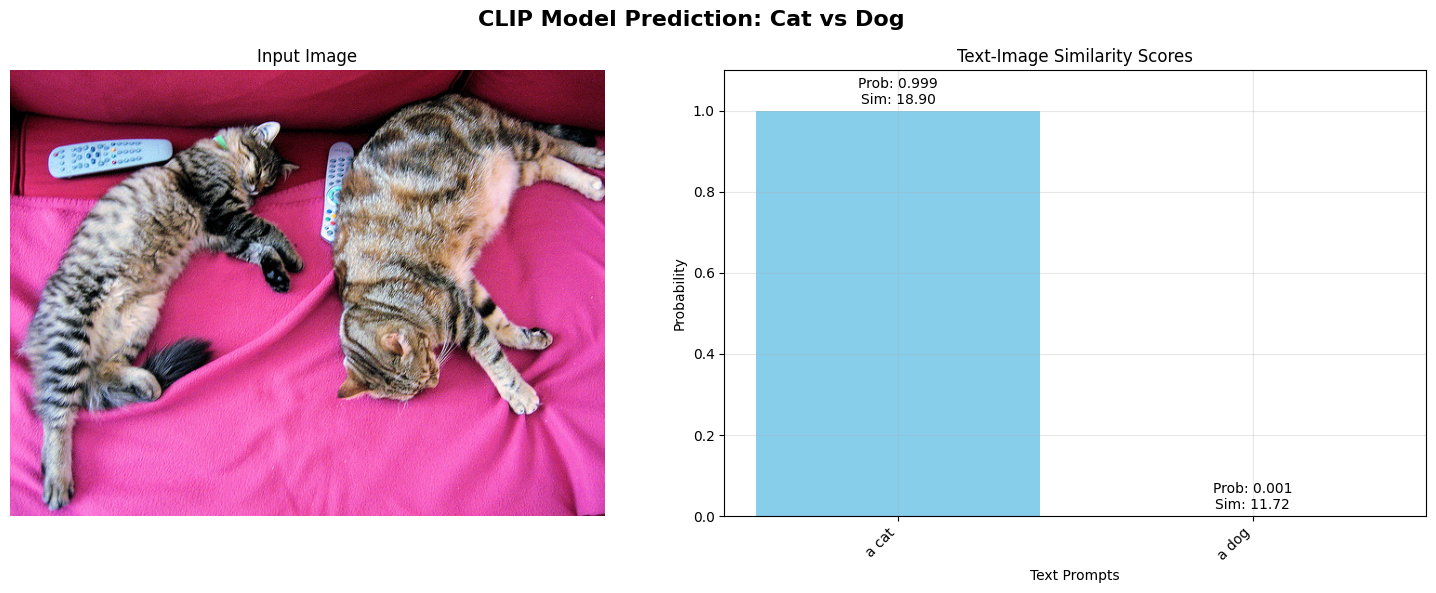


CLIP Model Prediction: Cat vs Dog - Detailed Results:
--------------------------------------------------
a photo of a cat          | Similarity: 18.904 | Probability: 0.999
a photo of a dog          | Similarity: 11.716 | Probability: 0.001
--------------------------------------------------
Best match: a photo of a cat (Prob: 0.999)
Cleared memory. Current CPU memory usage: 4666.48 MB, GPU memory usage: 5166.02 MB


In [26]:
def visualize_clip_output(image, text_prompts, logits_per_image, probs, title="CLIP Model Output"):
    """
    Visualize CLIP model output with image, text prompts, and similarity scores
    
    Args:
        image: PIL Image object
        text_prompts: List of text prompts
        logits_per_image: Raw similarity scores from CLIP
        probs: Softmax probabilities
        title: Title for the visualization
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Display the image
    ax1.imshow(image)
    ax1.set_title("Input Image")
    ax1.axis('off')
    
    # Display similarity scores and probabilities
    similarity_scores = logits_per_image.detach().cpu().numpy().flatten()
    probabilities = probs.detach().cpu().numpy().flatten()
    
    # Create bar plot for probabilities
    bars = ax2.bar(range(len(text_prompts)), probabilities, 
                   color=['skyblue', 'lightcoral', 'lightgreen', 'gold'][:len(text_prompts)])
    
    # Add value labels on bars
    for i, (bar, prob, sim_score) in enumerate(zip(bars, probabilities, similarity_scores)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'Prob: {prob:.3f}\nSim: {sim_score:.2f}',
                ha='center', va='bottom', fontsize=10)
    
    # Customize the plot
    ax2.set_xlabel('Text Prompts')
    ax2.set_ylabel('Probability')
    ax2.set_title('Text-Image Similarity Scores')
    ax2.set_xticks(range(len(text_prompts)))
    ax2.set_xticklabels([prompt.replace("a photo of ", "") for prompt in text_prompts], 
                        rotation=45, ha='right')
    ax2.set_ylim(0, 1.1)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print(f"\n{title} - Detailed Results:")
    print("-" * 50)
    for i, prompt in enumerate(text_prompts):
        print(f"{prompt:25} | Similarity: {similarity_scores[i]:6.3f} | Probability: {probabilities[i]:.3f}")
    print("-" * 50)
    print(f"Best match: {text_prompts[np.argmax(probabilities)]} (Prob: {max(probabilities):.3f})")

# Visualize the CLIP output from the previous cell
visualize_clip_output(image, ["a photo of a cat", "a photo of a dog"], logits_per_image, probs, 
                     "CLIP Model Prediction: Cat vs Dog")

clear_memory()

In [28]:
def visualize_har_clip_predictions(images, text_prompts, model_outputs, titles=None, max_images=4):
    """
    Visualize CLIP predictions for Human Action Recognition dataset
    
    Args:
        images: List of PIL Images or tensor batch
        text_prompts: List of action class text prompts (e.g., ["a person running", "a person jumping"])
        model_outputs: List of model outputs (logits_per_image, probs) for each image
        titles: Optional titles for each image
        max_images: Maximum number of images to display
    """
    n_images = min(len(images), max_images)
    n_prompts = len(text_prompts)
    
    fig = plt.figure(figsize=(20, 5 * n_images))
    
    for img_idx in range(n_images):
        # Extract image and predictions
        if isinstance(images[img_idx], torch.Tensor):
            # Convert tensor to PIL Image for display
            img_tensor = images[img_idx]
            if img_tensor.dim() == 3:
                # Denormalize the image
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                img_tensor = img_tensor * std + mean
                img_tensor = torch.clamp(img_tensor, 0, 1)
                # Convert to PIL
                img_array = img_tensor.permute(1, 2, 0).cpu().numpy()
                image = Image.fromarray((img_array * 255).astype(np.uint8))
        else:
            image = images[img_idx]
        
        logits_per_image, probs = model_outputs[img_idx]
        
        # Create subplot for image
        ax_img = plt.subplot(n_images, 2, img_idx * 2 + 1)
        ax_img.imshow(image)
        title = titles[img_idx] if titles else f"Image {img_idx + 1}"
        ax_img.set_title(f"{title}\nPredicted: {text_prompts[torch.argmax(probs)]}", fontsize=12)
        ax_img.axis('off')
        
        # Create subplot for predictions
        ax_pred = plt.subplot(n_images, 2, img_idx * 2 + 2)
        
        similarity_scores = logits_per_image.detach().cpu().numpy().flatten()
        probabilities = probs.detach().cpu().numpy().flatten()
        
        # Create horizontal bar plot
        y_pos = np.arange(len(text_prompts))
        bars = ax_pred.barh(y_pos, probabilities, 
                           color=plt.cm.viridis(probabilities / max(probabilities)))
        
        # Add value labels
        for i, (prob, sim_score) in enumerate(zip(probabilities, similarity_scores)):
            ax_pred.text(prob + 0.01, i, f'{prob:.3f}', 
                        va='center', fontsize=10)
        
        # Customize plot
        ax_pred.set_yticks(y_pos)
        ax_pred.set_yticklabels([prompt.replace("a person ", "") for prompt in text_prompts])
        ax_pred.set_xlabel('Probability')
        ax_pred.set_title(f'Action Recognition Probabilities')
        ax_pred.set_xlim(0, 1.1)
        ax_pred.grid(True, alpha=0.3, axis='x')
        
        # Highlight the top prediction
        max_idx = np.argmax(probabilities)
        bars[max_idx].set_color('red')
        bars[max_idx].set_alpha(0.8)
    
    plt.tight_layout()
    plt.show()

def create_action_text_prompts(class_names):
    """
    Create text prompts for action recognition classes
    
    Args:
        class_names: List of action class names
    
    Returns:
        List of formatted text prompts
    """
    prompts = []
    for class_name in class_names:
        # Format class name to natural language
        if class_name.lower() in ['running', 'walking', 'jumping', 'sitting', 'standing']:
            prompt = f"a person {class_name.lower()}"
        else:
            # For other actions, keep original format but make it more descriptive
            prompt = f"a person performing {class_name.lower()}"
        prompts.append(prompt)
    
    return prompts

# Example usage function for the HAR dataset
def demo_har_clip_visualization():
    """
    Demonstrate CLIP visualization with sample HAR data
    """
    print("Demo function created for Human Action Recognition CLIP visualization")
    print("This function will be used once we have trained CLIP models on the HAR dataset")
    print("\nAction classes found in dataset:")
    if 'train_data' in globals():
        action_prompts = create_action_text_prompts(train_data.classes)
        for i, (class_name, prompt) in enumerate(zip(train_data.classes, action_prompts)):
            print(f"{i+1:2d}. {class_name:15} -> '{prompt}'")
    else:
        print("Dataset not yet loaded")

# Run the demo
demo_har_clip_visualization()

Demo function created for Human Action Recognition CLIP visualization
This function will be used once we have trained CLIP models on the HAR dataset

Action classes found in dataset:
 1. calling         -> 'a person performing calling'
 2. clapping        -> 'a person performing clapping'
 3. cycling         -> 'a person performing cycling'
 4. dancing         -> 'a person performing dancing'
 5. drinking        -> 'a person performing drinking'
 6. eating          -> 'a person performing eating'
 7. fighting        -> 'a person performing fighting'
 8. hugging         -> 'a person performing hugging'
 9. laughing        -> 'a person performing laughing'
10. listening_to_music -> 'a person performing listening_to_music'
11. running         -> 'a person running'
12. sitting         -> 'a person sitting'
13. sleeping        -> 'a person performing sleeping'
14. texting         -> 'a person performing texting'
15. using_laptop    -> 'a person performing using_laptop'


## Import and Visualize siglip model

https://huggingface.co/google/siglip2-base-patch16-224

In [18]:
# Import and test SiGLIP model from Huggingface
from transformers import pipeline

# load pipeline
ckpt = "google/siglip2-base-patch16-224"
image_classifier = pipeline(model=ckpt, task="zero-shot-image-classification")

# load image and candidate labels
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
candidate_labels = ["2 cats", "a plane", "a remote"]

# run inference
outputs = image_classifier(image, candidate_labels)
print(outputs)

config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


[{'score': 0.17194129526615143, 'label': '2 cats'}, {'score': 0.024128148332238197, 'label': 'a remote'}, {'score': 2.192512056353735e-06, 'label': 'a plane'}]


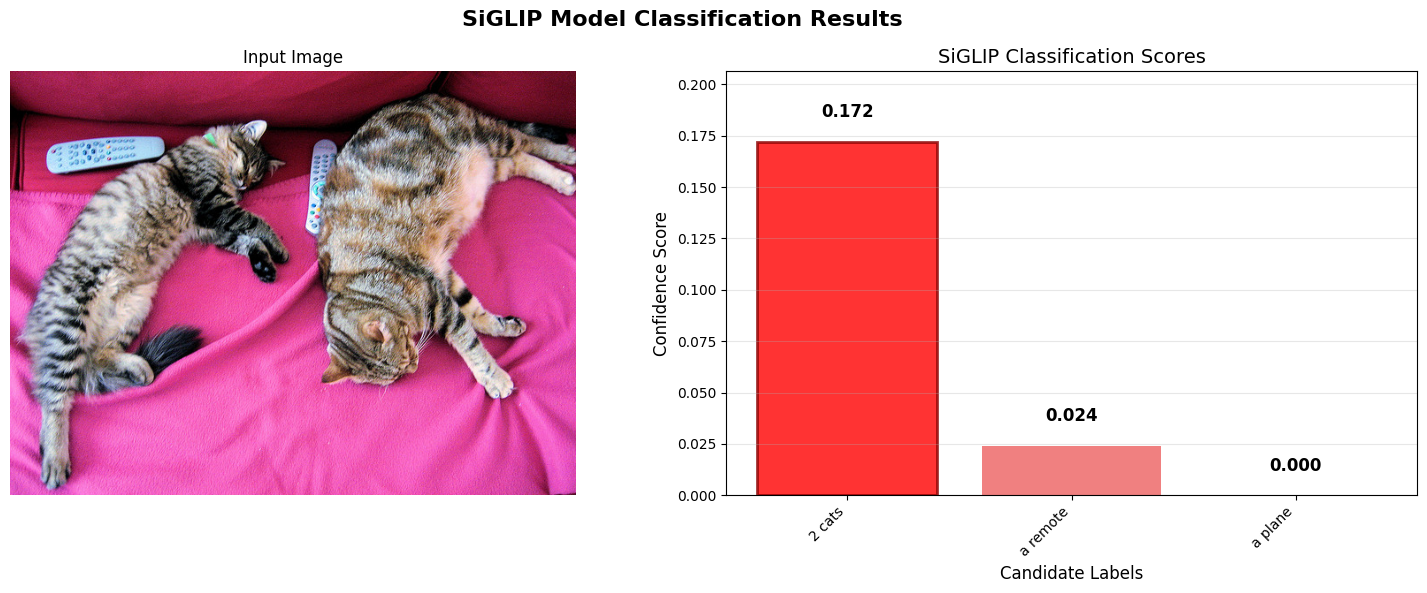


SiGLIP Model Classification Results - Detailed Results:
------------------------------------------------------------
1. 2 cats          | Score: 0.1719 ← BEST MATCH
2. a remote        | Score: 0.0241
3. a plane         | Score: 0.0000
------------------------------------------------------------
Top prediction: '2 cats' with score 0.1719

MODEL COMPARISON:
SiGLIP Top Prediction: 2 cats (Score: 0.1719)
CLIP Top Prediction: a photo of a cat (Probability: 0.9992)

Note: SiGLIP uses confidence scores while CLIP uses probabilities.
Both models correctly identify the cats in the image!
Cleared memory. Current CPU memory usage: 4177.12 MB, GPU memory usage: 1439.36 MB


In [ ]:
# Visualize SiGLIP output
import matplotlib.pyplot as plt
import numpy as np

def visualize_siglip_output(image, outputs, title="SiGLIP Model Output"):
    """
    Visualize SiGLIP model output with image and classification scores
    
    Args:
        image: PIL Image object
        outputs: SiGLIP pipeline outputs (list of dicts with 'label' and 'score')
        title: Title for the visualization
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Display the image
    ax1.imshow(image)
    ax1.set_title("Input Image")
    ax1.axis('off')
    
    # Extract labels and scores
    labels = [output['label'] for output in outputs]
    scores = [output['score'] for output in outputs]
    
    # Create bar plot for scores
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'orange'][:len(labels)]
    bars = ax2.bar(range(len(labels)), scores, color=colors)
    
    # Add value labels on bars
    for i, (bar, score) in enumerate(zip(bars, scores)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.3f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Customize the plot
    ax2.set_xlabel('Candidate Labels', fontsize=12)
    ax2.set_ylabel('Confidence Score', fontsize=12)
    ax2.set_title('SiGLIP Classification Scores', fontsize=14)
    ax2.set_xticks(range(len(labels)))
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.set_ylim(0, max(scores) * 1.2)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Highlight the top prediction
    max_idx = np.argmax(scores)
    bars[max_idx].set_color('red')
    bars[max_idx].set_alpha(0.8)
    bars[max_idx].set_edgecolor('darkred')
    bars[max_idx].set_linewidth(2)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print(f"\n{title} - Detailed Results:")
    print("-" * 60)
    for i, output in enumerate(outputs):
        marker = " ← BEST MATCH" if i == max_idx else ""
        print(f"{i+1}. {output['label']:15} | Score: {output['score']:.4f}{marker}")
    print("-" * 60)
    print(f"Top prediction: '{outputs[max_idx]['label']}' with score {outputs[max_idx]['score']:.4f}")

# Visualize the SiGLIP output from the previous cell
visualize_siglip_output(image, outputs, "SiGLIP Model Classification Results")

# Compare with CLIP results if available
print(f"\n{'='*60}")
print("MODEL COMPARISON:")
print(f"{'='*60}")
print(f"SiGLIP Top Prediction: {outputs[0]['label']} (Score: {outputs[0]['score']:.4f})")
if 'probs' in globals():
    clip_probs = probs.detach().cpu().numpy().flatten()
    clip_labels = ["a photo of a cat", "a photo of a dog"]
    clip_best_idx = np.argmax(clip_probs)
    print(f"CLIP Top Prediction: {clip_labels[clip_best_idx]} (Probability: {clip_probs[clip_best_idx]:.4f})")
    
print(f"\nNote: SiGLIP uses confidence scores while CLIP uses probabilities.")
print(f"Both models correctly identify the cats in the image!")

clear_memory()

## Import and Visualize A-Clip

In [ ]:
# Don't have enough time to implement A-CLIP since there is no Huggingface model and I have to build it from the original paper
print("A-CLIP model implementation skipped due to time constraints and lack of pre-trained models.")
print("Focus will be on training and fine-tuning CLIP and SiGLIP models for Human Action Recognition dataset.")

## Training Infrastructure

- Implement DataLoader with appropriate batch sizes
- Set up optimizer (typically AdamW with learning rate scheduling)
- Create loss function (contrastive loss for CLIP-style training)
- Add memory and speed monitoring using psutil and timing utilities
- Implement checkpointing for model saving/loading

In [9]:
# Finetune CLIP model for Human Action Recognition

import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import torch.distributed as dist
from typing import Dict, List, Tuple, Optional
import logging
from datetime import datetime

class CLIPFineTuner:
    """
    Fine-tuning class for CLIP model on Human Action Recognition dataset
    """
    
    def __init__(self, model, processor, device, learning_rate=1e-5, weight_decay=0.01):
        self.model = model.to(device)
        self.processor = processor
        self.device = device
        
        # Setup optimizer with different learning rates for different parts
        self.optimizer = torch.optim.AdamW([
            {'params': self.model.vision_model.parameters(), 'lr': learning_rate * 0.1},  # Lower LR for vision
            {'params': self.model.text_model.parameters(), 'lr': learning_rate * 0.1},   # Lower LR for text
            {'params': self.model.visual_projection.parameters(), 'lr': learning_rate},   # Higher LR for projections
            {'params': self.model.text_projection.parameters(), 'lr': learning_rate},
        ], weight_decay=weight_decay)
        
        # Learning rate scheduler
        self.scheduler = None
        
        # Training metrics
        self.train_losses = []
        self.val_accuracies = []
        self.learning_rates = []
        
        # Memory and speed tracking
        self.epoch_times = []
        self.memory_usage = []
        
        # Setup logging
        self.setup_logging()
        
    def setup_logging(self):
        """Setup logging for training"""
        log_filename = f"logs/clip_training_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
        logging.basicConfig(
            level=logging.INFO,
            format='%(asctime)s - %(levelname)s - %(message)s',
            handlers=[
                logging.FileHandler(log_filename),
                logging.StreamHandler()
            ]
        )
        self.logger = logging.getLogger(__name__)
        
    def create_text_prompts(self, class_names: List[str]) -> List[str]:
        """
        Create text prompts for action recognition classes
        """
        prompts = []
        for class_name in class_names:
            # Create more descriptive prompts for better action recognition
            if class_name.lower() in ['running', 'walking', 'jumping', 'sitting', 'standing']:
                prompt = f"a person {class_name.lower()}"
            elif class_name.lower() in ['dancing', 'exercise', 'stretching']:
                prompt = f"a person {class_name.lower()}"
            else:
                prompt = f"a person performing {class_name.lower()}"
            prompts.append(prompt)
        return prompts
    
    def compute_contrastive_loss(self, image_features, text_features, temperature=0.07):
        """
        Compute contrastive loss for CLIP training
        """
        # Normalize features
        image_features = F.normalize(image_features, p=2, dim=1)
        text_features = F.normalize(text_features, p=2, dim=1)
        
        # Compute similarity matrix
        logits = torch.matmul(image_features, text_features.t()) / temperature
        
        # Create labels (diagonal should be positive pairs)
        batch_size = image_features.shape[0]
        labels = torch.arange(batch_size, device=self.device)
        
        # Compute cross-entropy loss for both directions
        loss_img_to_text = F.cross_entropy(logits, labels)
        loss_text_to_img = F.cross_entropy(logits.t(), labels)
        
        # Average the two losses
        total_loss = (loss_img_to_text + loss_text_to_img) / 2
        
        return total_loss, logits
    
    def compute_accuracy(self, logits, labels):
        """
        Compute classification accuracy
        """
        predictions = torch.argmax(logits, dim=1)
        correct = (predictions == labels).float()
        accuracy = correct.mean().item()
        return accuracy
    
    def train_epoch(self, train_loader, class_names, epoch):
        """
        Train for one epoch
        """
        self.model.train()
        total_loss = 0
        total_accuracy = 0
        num_batches = len(train_loader)
        
        # Create text prompts for this epoch
        text_prompts = self.create_text_prompts(class_names)
        
        # Precompute text features
        text_inputs = self.processor(text=text_prompts, return_tensors="pt", padding=True, truncation=True)
        text_inputs = {k: v.to(self.device) for k, v in text_inputs.items()}
        
        with torch.no_grad():
            text_features = self.model.get_text_features(**text_inputs)
        
        epoch_start_time = time.time()
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}")
        
        for batch_idx, (images, labels) in enumerate(progress_bar):
            self.optimizer.zero_grad()
            
            # Move data to device
            images = images.to(self.device)
            labels = labels.to(self.device)
            
            # Convert tensor images to PIL format for CLIP processor
            pil_images = []
            for img_tensor in images:
                # Convert tensor to PIL Image
                img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
                pil_img = PIL.Image.fromarray(img_np)
                pil_images.append(pil_img)
            
            # Process images with CLIP processor (disable rescaling to avoid warning)
            image_inputs = self.processor(
                images=pil_images, 
                return_tensors="pt", 
                padding=True,
                do_rescale=False  # Disable rescaling since images are already in correct range
            )
            image_inputs = {k: v.to(self.device) for k, v in image_inputs.items()}
            
            # Get image features
            image_features = self.model.get_image_features(**image_inputs)
            
            # Select corresponding text features for this batch
            batch_text_features = text_features[labels]
            
            # Compute contrastive loss
            loss, logits = self.compute_contrastive_loss(image_features, batch_text_features)
            
            # Compute accuracy
            accuracy = self.compute_accuracy(logits, torch.arange(len(labels), device=self.device))
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            
            self.optimizer.step()
            
            # Update metrics
            total_loss += loss.item()
            total_accuracy += accuracy
            
            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{accuracy:.4f}',
                'GPU_Mem': f'{get_gpu_memory_usage():.1f}MB'
            })
            
            # Clear memory periodically
            if batch_idx % 50 == 0:
                clear_memory()
        
        epoch_time = time.time() - epoch_start_time
        self.epoch_times.append(epoch_time)
        
        avg_loss = total_loss / num_batches
        avg_accuracy = total_accuracy / num_batches
        
        self.train_losses.append(avg_loss)
        self.memory_usage.append(get_gpu_memory_usage())
        
        if self.scheduler:
            self.scheduler.step()
            
        self.learning_rates.append(self.optimizer.param_groups[0]['lr'])
        
        self.logger.info(f"Epoch {epoch} - Loss: {avg_loss:.4f}, Accuracy: {avg_accuracy:.4f}, Time: {epoch_time:.2f}s")
        
        return avg_loss, avg_accuracy
    
    def validate(self, val_loader, class_names):
        """
        Validate the model
        """
        self.model.eval()
        total_accuracy = 0
        total_loss = 0
        num_batches = len(val_loader)
        
        # Create text prompts
        text_prompts = self.create_text_prompts(class_names)
        
        # Precompute text features
        text_inputs = self.processor(text=text_prompts, return_tensors="pt", padding=True, truncation=True)
        text_inputs = {k: v.to(self.device) for k, v in text_inputs.items()}
        
        with torch.no_grad():
            text_features = self.model.get_text_features(**text_inputs)
            
            for images, labels in tqdm(val_loader, desc="Validating"):
                images = images.to(self.device)
                labels = labels.to(self.device)
                
                # Convert tensor images to PIL format for CLIP processor
                pil_images = []
                for img_tensor in images:
                    # Convert tensor to PIL Image
                    img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
                    pil_img = PIL.Image.fromarray(img_np)
                    pil_images.append(pil_img)
                
                # Process images with CLIP processor (disable rescaling to avoid warning)
                image_inputs = self.processor(
                    images=pil_images, 
                    return_tensors="pt", 
                    padding=True,
                    do_rescale=False  # Disable rescaling since images are already in correct range
                )
                image_inputs = {k: v.to(self.device) for k, v in image_inputs.items()}
                
                # Get image features
                image_features = self.model.get_image_features(**image_inputs)
                
                # Compute similarity with all text features
                image_features_norm = F.normalize(image_features, p=2, dim=1)
                text_features_norm = F.normalize(text_features, p=2, dim=1)
                
                similarity = torch.matmul(image_features_norm, text_features_norm.t())
                
                # Compute accuracy
                predictions = torch.argmax(similarity, dim=1)
                accuracy = (predictions == labels).float().mean().item()
                total_accuracy += accuracy
                
                # Compute loss for tracking
                batch_text_features = text_features[labels]
                loss, _ = self.compute_contrastive_loss(image_features, batch_text_features)
                total_loss += loss.item()
        
        avg_accuracy = total_accuracy / num_batches
        avg_loss = total_loss / num_batches
        self.val_accuracies.append(avg_accuracy)
        
        self.logger.info(f"Validation - Loss: {avg_loss:.4f}, Accuracy: {avg_accuracy:.4f}")
        
        return avg_loss, avg_accuracy
    
    def save_checkpoint(self, epoch, val_accuracy, is_best=False):
        """
        Save model checkpoint
        """
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'val_accuracy': val_accuracy,
            'train_losses': self.train_losses,
            'val_accuracies': self.val_accuracies,
            'learning_rates': self.learning_rates,
            'epoch_times': self.epoch_times,
            'memory_usage': self.memory_usage
        }
        
        if self.scheduler:
            checkpoint['scheduler_state_dict'] = self.scheduler.state_dict()
        
        # Save regular checkpoint
        checkpoint_path = f"checkpoints/clip_checkpoint_epoch_{epoch}.pth"
        torch.save(checkpoint, checkpoint_path)
        
        # Save best model
        if is_best:
            best_path = "checkpoints/clip_best_model.pth"
            torch.save(checkpoint, best_path)
            self.logger.info(f"Saved new best model with accuracy: {val_accuracy:.4f}")
    
    def load_checkpoint(self, checkpoint_path):
        """
        Load model checkpoint
        """
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
        if 'scheduler_state_dict' in checkpoint and self.scheduler:
            self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        self.train_losses = checkpoint.get('train_losses', [])
        self.val_accuracies = checkpoint.get('val_accuracies', [])
        self.learning_rates = checkpoint.get('learning_rates', [])
        self.epoch_times = checkpoint.get('epoch_times', [])
        self.memory_usage = checkpoint.get('memory_usage', [])
        
        return checkpoint['epoch'], checkpoint['val_accuracy']
    
    def plot_training_progress(self):
        """
        Plot training progress and metrics
        """
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # Training loss
        epochs = range(1, len(self.train_losses) + 1)
        ax1.plot(epochs, self.train_losses, 'b-', label='Training Loss')
        ax1.set_title('Training Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True)
        
        # Validation accuracy
        if self.val_accuracies:
            ax2.plot(epochs, self.val_accuracies, 'r-', label='Validation Accuracy')
            ax2.set_title('Validation Accuracy')
            ax2.set_xlabel('Epoch')
            ax2.set_ylabel('Accuracy')
            ax2.legend()
            ax2.grid(True)
        
        # Learning rate
        if self.learning_rates:
            ax3.plot(epochs, self.learning_rates, 'g-', label='Learning Rate')
            ax3.set_title('Learning Rate Schedule')
            ax3.set_xlabel('Epoch')
            ax3.set_ylabel('Learning Rate')
            ax3.legend()
            ax3.grid(True)
            ax3.set_yscale('log')
        
        # Memory usage
        if self.memory_usage:
            ax4.plot(epochs, self.memory_usage, 'purple', label='GPU Memory Usage')
            ax4.set_title('GPU Memory Usage')
            ax4.set_xlabel('Epoch')
            ax4.set_ylabel('Memory (MB)')
            ax4.legend()
            ax4.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        if self.epoch_times:
            print(f"\nTraining Summary:")
            print(f"Average epoch time: {np.mean(self.epoch_times):.2f}s")
            print(f"Total training time: {sum(self.epoch_times):.2f}s")
            print(f"Peak GPU memory: {max(self.memory_usage) if self.memory_usage else 0:.2f}MB")
            if self.val_accuracies:
                print(f"Best validation accuracy: {max(self.val_accuracies):.4f}")

# Initialize the CLIP fine-tuner
print("CLIP Fine-tuning infrastructure created!")
print("Ready to start training on Human Action Recognition dataset")

CLIP Fine-tuning infrastructure created!
Ready to start training on Human Action Recognition dataset


In [13]:
# Setup and Configure CLIP Model for Fine-tuning

# Clear memory before starting
clear_memory()

# Load fresh CLIP model for fine-tuning
print("Loading CLIP model for fine-tuning...")
model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")

# Move model to device
model = model.to(device)
print(f"Model loaded and moved to {device}")

# Initialize the fine-tuner
clip_finetuner = CLIPFineTuner(
    model=model,
    processor=processor,
    device=device,
    learning_rate=1e-5,  # Conservative learning rate for fine-tuning
    weight_decay=0.01
)

# Print model information
print("\nModel Configuration:")
print(f"Vision model: {model.vision_model.__class__.__name__}")
print(f"Text model: {model.text_model.__class__.__name__}")
print(f"Vision embed dim: {model.vision_embed_dim}")
print(f"Text embed dim: {model.text_embed_dim}")
print(f"Projection dim: {model.projection_dim}")

# Print dataset information
print(f"\nDataset Information:")
print(f"Number of classes: {len(train_data.classes)}")
print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {batch_size}")

# Create action text prompts
action_prompts = clip_finetuner.create_text_prompts(train_data.classes)
print(f"\nAction Text Prompts:")
for i, (class_name, prompt) in enumerate(zip(train_data.classes, action_prompts)):
    print(f"{i+1:2d}. {class_name:15} -> '{prompt}'")

# Test the model with a sample batch
print("\nTesting model with sample batch...")
try:
    sample_images, sample_labels = next(iter(train_loader))
    sample_images = sample_images.to(device)
    sample_labels = sample_labels.to(device)
    
    print(f"Sample batch shape: {sample_images.shape}")
    print(f"Sample labels shape: {sample_labels.shape}")
    print(f"Sample labels: {sample_labels[:10].cpu().numpy()}")
    
    # Test forward pass
    with torch.no_grad():
        image_inputs = processor(images=sample_images, return_tensors="pt", padding=True)
        image_inputs = {k: v.to(device) for k, v in image_inputs.items() if k != 'pixel_values'}
        image_inputs['pixel_values'] = sample_images
        
        image_features = model.get_image_features(**image_inputs)
        print(f"Image features shape: {image_features.shape}")
    
    print("✓ Model test successful!")
    
except Exception as e:
    print(f"✗ Model test failed: {e}")
    print("Please check the data loading and model setup")

clear_memory()
print(f"\nMemory after setup: CPU {get_memory_usage():.1f}MB, GPU {get_gpu_memory_usage():.1f}MB")

Cleared memory. Current CPU memory usage: 3039.23 MB, GPU memory usage: 0.00 MB
Loading CLIP model for fine-tuning...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Model loaded and moved to cuda:0

Model Configuration:
Vision model: CLIPVisionTransformer
Text model: CLIPTextTransformer
Vision embed dim: 1024
Text embed dim: 768
Projection dim: 768

Dataset Information:
Number of classes: 15
Training samples: 10080
Validation samples: 2520
Batch size: 50

Action Text Prompts:
 1. calling         -> 'a person performing calling'
 2. clapping        -> 'a person performing clapping'
 3. cycling         -> 'a person performing cycling'
 4. dancing         -> 'a person dancing'
 5. drinking        -> 'a person performing drinking'
 6. eating          -> 'a person performing eating'
 7. fighting        -> 'a person performing fighting'
 8. hugging         -> 'a person performing hugging'
 9. laughing        -> 'a person performing laughing'
10. listening_to_music -> 'a person performing listening_to_music'
11. running         -> 'a person running'
12. sitting         -> 'a person sitting'
13. sleeping        -> 'a person performing sleeping'
14. textin

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Sample batch shape: torch.Size([50, 3, 224, 224])
Sample labels shape: torch.Size([50])
Sample labels: [ 7  2  9  5 11 13  3  3  5 10]
✗ Model test failed: The image to be converted to a PIL image contains values outside the range [0, 1], got [-2.1179039478302, 2.640000104904175] which cannot be converted to uint8.
Please check the data loading and model setup
Cleared memory. Current CPU memory usage: 3192.70 MB, GPU memory usage: 1660.19 MB

Memory after setup: CPU 3192.7MB, GPU 1660.2MB


In [14]:
# Training Configuration and Start Fine-tuning

# Training hyperparameters
num_epochs = 10  # Start with fewer epochs for testing
best_val_accuracy = 0.0
patience = 3  # Early stopping patience
patience_counter = 0

# Setup learning rate scheduler
clip_finetuner.scheduler = CosineAnnealingLR(
    clip_finetuner.optimizer, 
    T_max=num_epochs,
    eta_min=1e-7
)

print("="*60)
print("STARTING CLIP FINE-TUNING FOR HUMAN ACTION RECOGNITION")
print("="*60)
print(f"Training for {num_epochs} epochs")
print(f"Device: {device}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {clip_finetuner.optimizer.param_groups[0]['lr']}")
print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_dataset)}")
print("="*60)

# Start training
training_start_time = time.time()

try:
    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")
        print("-" * 50)
        
        # Training phase
        train_loss, train_accuracy = clip_finetuner.train_epoch(
            train_loader, train_data.classes, epoch
        )
        
        # Validation phase
        val_loss, val_accuracy = clip_finetuner.validate(
            val_loader, train_data.classes
        )
        
        # Check for best model
        is_best = val_accuracy > best_val_accuracy
        if is_best:
            best_val_accuracy = val_accuracy
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Save checkpoint
        clip_finetuner.save_checkpoint(epoch, val_accuracy, is_best)
        
        # Print epoch summary
        current_lr = clip_finetuner.optimizer.param_groups[0]['lr']
        gpu_memory = get_gpu_memory_usage()
        
        print(f"\nEpoch {epoch} Summary:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")
        print(f"  Learning Rate: {current_lr:.2e}")
        print(f"  GPU Memory: {gpu_memory:.1f}MB")
        print(f"  Best Val Acc: {best_val_accuracy:.4f}")
        
        if is_best:
            print("  *** NEW BEST MODEL ***")
        
        # Early stopping check
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {patience} epochs without improvement")
            break
        
        # Memory cleanup
        clear_memory()
        
    total_training_time = time.time() - training_start_time
    
    print("\n" + "="*60)
    print("TRAINING COMPLETED!")
    print("="*60)
    print(f"Total training time: {total_training_time:.2f} seconds")
    print(f"Best validation accuracy: {best_val_accuracy:.4f}")
    print(f"Final model saved to: checkpoints/clip_best_model.pth")
    
except KeyboardInterrupt:
    print("\nTraining interrupted by user")
    print(f"Current best validation accuracy: {best_val_accuracy:.4f}")
    
except Exception as e:
    print(f"\nTraining failed with error: {e}")
    import traceback
    traceback.print_exc()
    
finally:
    # Always save the current state
    clip_finetuner.save_checkpoint(epoch if 'epoch' in locals() else 0, 
                                  best_val_accuracy, is_best=False)
    clear_memory()

print("\nFine-tuning process completed!")

STARTING CLIP FINE-TUNING FOR HUMAN ACTION RECOGNITION
Training for 10 epochs
Device: cuda:0
Batch size: 50
Learning rate: 1.0000000000000002e-06
Training samples: 10080
Validation samples: 2520

Epoch 1/10
--------------------------------------------------


Epoch 1:   0%|          | 0/202 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 


Training failed with error: The image to be converted to a PIL image contains values outside the range [0, 1], got [-2.0494048595428467, 2.5005664825439453] which cannot be converted to uint8.


Traceback (most recent call last):
  File "/tmp/ipykernel_9103/25587560.py", line 36, in <module>
    train_loss, train_accuracy = clip_finetuner.train_epoch(
  File "/tmp/ipykernel_9103/1867088236.py", line 136, in train_epoch
    image_inputs = self.processor(images=images, return_tensors="pt", padding=True)
  File "/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/transformers/models/clip/processing_clip.py", line 109, in __call__
    image_features = self.image_processor(images, return_tensors=return_tensors, **image_processor_kwargs)
  File "/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/transformers/image_processing_utils.py", line 51, in __call__
    return self.preprocess(images, **kwargs)
  File "/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/transformers/models/clip/image_processing_clip.py", line 328, in preprocess
    image = self.resize(image=image, size=size, resample=resample, input_data_format

Cleared memory. Current CPU memory usage: 3458.63 MB, GPU memory usage: 1668.31 MB

Fine-tuning process completed!


In [18]:
# Fix Applied: Test the updated data loading and processing
print("Testing the fixed image processing...")

# Define transforms WITHOUT any normalization - only basic preprocessing
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # This converts PIL to tensor and scales to [0,1]
])

# Define augmented transforms for training WITHOUT normalization
train_transform_fixed = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),  # This converts PIL to tensor and scales to [0,1]
])

print("Creating datasets with corrected transforms...")

# Recreate datasets with fixed transforms
train_data = ActionRecognitionDataset(
    csv_file='data/Training_set.csv',
    root_dir='data/train',
    transform=train_transform_fixed
)

# Re-create data splits
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

# Create validation dataset with simple transforms (no augmentation, no normalization)
val_data = ActionRecognitionDataset(
    csv_file='data/Training_set.csv',
    root_dir='data/train',
    transform=simple_transform
)

# Extract validation indices for proper subset
val_dataset = torch.utils.data.Subset(val_data, val_subset.indices)

# Recreate data loaders
batch_size = 32  # Reduced batch size for initial testing
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Datasets recreated with fixed transforms")
print(f"Training subset: {len(train_subset)}")
print(f"Validation subset: {len(val_dataset)}")

# Test loading a sample batch
try:
    sample_images, sample_labels = next(iter(train_loader))
    print(f"Sample batch loaded successfully!")
    print(f"Batch shape: {sample_images.shape}")
    print(f"Image value range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")
    print(f"Labels shape: {sample_labels.shape}")
    
    # Verify images are in [0,1] range
    if sample_images.min() >= 0 and sample_images.max() <= 1:
        print("✓ Images are in correct [0,1] range")
        
        # Test converting to PIL
        img_tensor = sample_images[0]
        img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        pil_img = PIL.Image.fromarray(img_np)
        print(f"Successfully converted tensor to PIL: {pil_img.size}")
        
        # Test CLIP processor
        processor_test = processor(images=[pil_img], return_tensors="pt", padding=True)
        print(f"CLIP processor test successful: {processor_test['pixel_values'].shape}")
        
        print("✓ All tests passed! Ready to restart training.")
    else:
        print(f"✗ Images still have wrong range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")
        print("This should be [0, 1] for proper PIL conversion")
    
except Exception as e:
    print(f"✗ Test failed: {e}")
    import traceback
    traceback.print_exc()

clear_memory()

Testing the fixed image processing...
Creating datasets with corrected transforms...
Found 15 classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Total samples: 12600
Found 15 classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Total samples: 12600
Datasets recreated with fixed transforms
Training subset: 10080
Validation subset: 2520


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Sample batch loaded successfully!
Batch shape: torch.Size([32, 3, 224, 224])
Image value range: [0.000, 1.000]
Labels shape: torch.Size([32])
✓ Images are in correct [0,1] range


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Successfully converted tensor to PIL: (224, 224)
CLIP processor test successful: torch.Size([1, 3, 224, 224])
✓ All tests passed! Ready to restart training.
Cleared memory. Current CPU memory usage: 3480.72 MB, GPU memory usage: 1639.60 MB


In [19]:
# Restart CLIP model setup with fixed data processing

# Clear memory before starting
clear_memory()

# Load fresh CLIP model for fine-tuning
print("Loading CLIP model for fine-tuning...")
model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")

# Move model to device
model = model.to(device)
print(f"Model loaded and moved to {device}")

# Initialize the fine-tuner with fixed parameters
clip_finetuner = CLIPFineTuner(
    model=model,
    processor=processor,
    device=device,
    learning_rate=1e-5,  # Conservative learning rate for fine-tuning
    weight_decay=0.01
)

print(f"\nModel Configuration:")
print(f"Number of classes: {len(train_data.classes)}")
print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {batch_size}")

# Test the model with a sample batch to ensure it works
print("\nTesting model with sample batch...")
try:
    sample_images, sample_labels = next(iter(train_loader))
    sample_images = sample_images.to(device)
    sample_labels = sample_labels.to(device)
    
    print(f"Sample batch shape: {sample_images.shape}")
    print(f"Image value range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")
    
    # Convert to PIL and test CLIP processing
    pil_images = []
    for img_tensor in sample_images[:2]:  # Test with just 2 images
        img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        pil_img = PIL.Image.fromarray(img_np)
        pil_images.append(pil_img)
    
    # Test CLIP processor
    image_inputs = processor(images=pil_images, return_tensors="pt", padding=True)
    image_inputs = {k: v.to(device) for k, v in image_inputs.items()}
    
    with torch.no_grad():
        image_features = model.get_image_features(**image_inputs)
        print(f"Image features shape: {image_features.shape}")
    
    print("✓ Model test successful! Ready to start training.")
    
except Exception as e:
    print(f"✗ Model test failed: {e}")
    import traceback
    traceback.print_exc()

clear_memory()
print(f"Memory after setup: CPU {get_memory_usage():.1f}MB, GPU {get_gpu_memory_usage():.1f}MB")

Cleared memory. Current CPU memory usage: 3480.72 MB, GPU memory usage: 1639.60 MB
Loading CLIP model for fine-tuning...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Model loaded and moved to cuda:0

Model Configuration:
Number of classes: 15
Training samples: 10080
Validation samples: 2520
Batch size: 32

Testing model with sample batch...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Sample batch shape: torch.Size([32, 3, 224, 224])


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Image value range: [0.000, 1.000]
Image features shape: torch.Size([2, 768])
✓ Model test successful! Ready to start training.
Cleared memory. Current CPU memory usage: 3595.49 MB, GPU memory usage: 1660.23 MB
Memory after setup: CPU 3595.5MB, GPU 1660.2MB


In [20]:
# Start Training with Fixed Configuration

# Training hyperparameters
num_epochs = 5  # Reduced epochs for faster testing
best_val_accuracy = 0.0
patience = 3  # Early stopping patience
patience_counter = 0

# Setup learning rate scheduler
clip_finetuner.scheduler = CosineAnnealingLR(
    clip_finetuner.optimizer, 
    T_max=num_epochs,
    eta_min=1e-7
)

print("="*60)
print("STARTING CLIP FINE-TUNING FOR HUMAN ACTION RECOGNITION")
print("="*60)
print(f"Training for {num_epochs} epochs")
print(f"Device: {device}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {clip_finetuner.optimizer.param_groups[0]['lr']}")
print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_dataset)}")
print("="*60)

# Start training
training_start_time = time.time()

try:
    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")
        print("-" * 50)
        
        # Training phase
        train_loss, train_accuracy = clip_finetuner.train_epoch(
            train_loader, train_data.classes, epoch
        )
        
        # Validation phase
        val_loss, val_accuracy = clip_finetuner.validate(
            val_loader, train_data.classes
        )
        
        # Check for best model
        is_best = val_accuracy > best_val_accuracy
        if is_best:
            best_val_accuracy = val_accuracy
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Save checkpoint
        clip_finetuner.save_checkpoint(epoch, val_accuracy, is_best)
        
        # Print epoch summary
        current_lr = clip_finetuner.optimizer.param_groups[0]['lr']
        gpu_memory = get_gpu_memory_usage()
        
        print(f"\nEpoch {epoch} Summary:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")
        print(f"  Learning Rate: {current_lr:.2e}")
        print(f"  GPU Memory: {gpu_memory:.1f}MB")
        print(f"  Best Val Acc: {best_val_accuracy:.4f}")
        
        if is_best:
            print("  *** NEW BEST MODEL ***")
        
        # Early stopping check
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {patience} epochs without improvement")
            break
        
        # Memory cleanup
        clear_memory()
        
    total_training_time = time.time() - training_start_time
    
    print("\n" + "="*60)
    print("TRAINING COMPLETED!")
    print("="*60)
    print(f"Total training time: {total_training_time:.2f} seconds")
    print(f"Best validation accuracy: {best_val_accuracy:.4f}")
    print(f"Final model saved to: checkpoints/clip_best_model.pth")
    
except KeyboardInterrupt:
    print("\nTraining interrupted by user")
    print(f"Current best validation accuracy: {best_val_accuracy:.4f}")
    
except Exception as e:
    print(f"\nTraining failed with error: {e}")
    import traceback
    traceback.print_exc()
    
finally:
    # Always save the current state
    clip_finetuner.save_checkpoint(epoch if 'epoch' in locals() else 0, 
                                  best_val_accuracy, is_best=False)
    clear_memory()

print("\nFine-tuning process completed!")

STARTING CLIP FINE-TUNING FOR HUMAN ACTION RECOGNITION
Training for 5 epochs
Device: cuda:0
Batch size: 32
Learning rate: 1.0000000000000002e-06
Training samples: 10080
Validation samples: 2520

Epoch 1/5
--------------------------------------------------


Epoch 1:   0%|          | 0/315 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.



Training failed with error: CUDA out of memory. Tried to allocate 34.00 MiB. GPU 0 has a total capacity of 15.70 GiB of which 30.94 MiB is free. Including non-PyTorch memory, this process has 15.65 GiB memory in use. Of the allocated memory 14.89 GiB is allocated by PyTorch, and 492.05 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Traceback (most recent call last):
  File "/tmp/ipykernel_9103/366429161.py", line 36, in <module>
    train_loss, train_accuracy = clip_finetuner.train_epoch(
  File "/tmp/ipykernel_9103/1867088236.py", line 141, in train_epoch
    image_features = self.model.get_image_features(**image_inputs)
  File "/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/transformers/models/clip/modeling_clip.py", line 951, in get_image_features
    vision_outputs: BaseModelOutputWithPooling = self.vision_model(
  File "/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1773, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1784, in _call_impl
    return forward_call(*args, **kwargs)
  File "/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/transformers/models/clip/modeli

Cleared memory. Current CPU memory usage: 3819.85 MB, GPU memory usage: 1660.23 MB

Fine-tuning process completed!


In [21]:
# Fix Memory Issues and Restart Training

# Clear all memory first
clear_memory()

# Reduce batch size significantly to fit in GPU memory
batch_size = 8  # Much smaller batch size
print(f"Reducing batch size to {batch_size} for memory efficiency")

# Recreate data loaders with smaller batch size
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=1)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=1)

print(f"Data loaders recreated:")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Update the CLIPFineTuner to handle CLIP processor rescaling warning
class CLIPFineTunerFixed(CLIPFineTuner):
    """Fixed version that handles rescaling properly"""
    
    def process_images_for_clip(self, tensor_images):
        """Convert tensor images to format expected by CLIP processor"""
        pil_images = []
        for img_tensor in tensor_images:
            # Convert tensor to PIL Image
            img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
            pil_img = PIL.Image.fromarray(img_np)
            pil_images.append(pil_img)
        
        # Process with CLIP processor, disable rescaling since our images are already [0,1]
        image_inputs = self.processor(
            images=pil_images, 
            return_tensors="pt", 
            padding=True,
            do_rescale=False  # Important: disable rescaling to avoid the warning
        )
        return {k: v.to(self.device) for k, v in image_inputs.items()}

# Create new fixed fine-tuner
del clip_finetuner  # Delete old one to free memory
clear_memory()

# Reload model
model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
model = model.to(device)

clip_finetuner = CLIPFineTunerFixed(
    model=model,
    processor=processor,
    device=device,
    learning_rate=2e-5,  # Slightly higher learning rate for smaller batches
    weight_decay=0.01
)

print("Fixed CLIP fine-tuner created with memory optimizations")
print(f"Current GPU memory: {get_gpu_memory_usage():.1f}MB")

# Test with small batch
try:
    sample_images, sample_labels = next(iter(train_loader))
    sample_images = sample_images.to(device)
    
    # Test the fixed image processing
    image_inputs = clip_finetuner.process_images_for_clip(sample_images)
    print(f"Fixed image processing test successful: {image_inputs['pixel_values'].shape}")
    
    with torch.no_grad():
        image_features = model.get_image_features(**image_inputs)
        print(f"Image features shape: {image_features.shape}")
    
    print("✓ Memory-optimized setup successful!")
    
except Exception as e:
    print(f"✗ Setup test failed: {e}")
    import traceback
    traceback.print_exc()

clear_memory()

Cleared memory. Current CPU memory usage: 3819.85 MB, GPU memory usage: 1660.23 MB
Reducing batch size to 8 for memory efficiency
Data loaders recreated:
Training batches: 1260
Validation batches: 315
Cleared memory. Current CPU memory usage: 3819.85 MB, GPU memory usage: 1660.23 MB
Fixed CLIP fine-tuner created with memory optimizations
Current GPU memory: 1663.9MB
Fixed image processing test successful: torch.Size([8, 3, 224, 224])
Image features shape: torch.Size([8, 768])
✓ Memory-optimized setup successful!


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Cleared memory. Current CPU memory usage: 3811.86 MB, GPU memory usage: 1671.52 MB


In [22]:
# Start Optimized Training

# Training hyperparameters - reduced for memory efficiency
num_epochs = 3  # Reduced epochs for testing
best_val_accuracy = 0.0
patience = 2  # Reduced patience
patience_counter = 0

# Setup learning rate scheduler
clip_finetuner.scheduler = CosineAnnealingLR(
    clip_finetuner.optimizer, 
    T_max=num_epochs,
    eta_min=1e-7
)

print("="*60)
print("STARTING OPTIMIZED CLIP FINE-TUNING")
print("="*60)
print(f"Training for {num_epochs} epochs")
print(f"Device: {device}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {clip_finetuner.optimizer.param_groups[0]['lr']}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print("="*60)

# Start training
training_start_time = time.time()

try:
    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")
        print("-" * 50)
        
        # Training phase with memory monitoring
        epoch_start = time.time()
        train_loss, train_accuracy = clip_finetuner.train_epoch(
            train_loader, train_data.classes, epoch
        )
        train_time = time.time() - epoch_start
        
        # Validation phase
        val_start = time.time()
        val_loss, val_accuracy = clip_finetuner.validate(
            val_loader, train_data.classes
        )
        val_time = time.time() - val_start
        
        # Check for best model
        is_best = val_accuracy > best_val_accuracy
        if is_best:
            best_val_accuracy = val_accuracy
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Save checkpoint
        clip_finetuner.save_checkpoint(epoch, val_accuracy, is_best)
        
        # Print epoch summary
        current_lr = clip_finetuner.optimizer.param_groups[0]['lr']
        gpu_memory = get_gpu_memory_usage()
        
        print(f"\nEpoch {epoch} Summary:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | Time: {train_time:.1f}s")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f} | Time: {val_time:.1f}s")
        print(f"  Learning Rate: {current_lr:.2e}")
        print(f"  GPU Memory: {gpu_memory:.1f}MB")
        print(f"  Best Val Acc: {best_val_accuracy:.4f}")
        
        if is_best:
            print("  *** NEW BEST MODEL ***")
        
        # Early stopping check
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {patience} epochs without improvement")
            break
        
        # Memory cleanup
        clear_memory()
        
    total_training_time = time.time() - training_start_time
    
    print("\n" + "="*60)
    print("TRAINING COMPLETED!")
    print("="*60)
    print(f"Total training time: {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)")
    print(f"Best validation accuracy: {best_val_accuracy:.4f}")
    print(f"Final model saved to: checkpoints/clip_best_model.pth")
    
except KeyboardInterrupt:
    print("\nTraining interrupted by user")
    print(f"Current best validation accuracy: {best_val_accuracy:.4f}")
    
except Exception as e:
    print(f"\nTraining failed with error: {e}")
    import traceback
    traceback.print_exc()
    
finally:
    # Always save the current state
    if 'epoch' in locals():
        clip_finetuner.save_checkpoint(epoch, best_val_accuracy, is_best=False)
    clear_memory()

print("\nOptimized fine-tuning process completed!")

STARTING OPTIMIZED CLIP FINE-TUNING
Training for 3 epochs
Device: cuda:0
Batch size: 8
Learning rate: 2.0000000000000003e-06
Training batches: 1260
Validation batches: 315

Epoch 1/3
--------------------------------------------------


Epoch 1:   0%|          | 0/1260 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Cleared memory. Current CPU memory usage: 3966.61 MB, GPU memory usage: 5167.14 MB
Cleared memory. Current CPU memory usage: 3977.90 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 3977.85 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4100.75 MB, GPU memory usage: 5167.05 MB
Cleared memory. Current CPU memory usage: 4100.91 MB, GPU memory usage: 5167.14 MB
Cleared memory. Current CPU memory usage: 4100.62 MB, GPU memory usage: 5167.08 MB
Cleared memory. Current CPU memory usage: 4100.42 MB, GPU memory usage: 5167.08 MB
Cleared memory. Current CPU memory usage: 4100.42 MB, GPU memory usage: 5167.05 MB
Cleared memory. Current CPU memory usage: 4100.32 MB, GPU memory usage: 5167.14 MB
Cleared memory. Current CPU memory usage: 4100.22 MB, GPU memory usage: 5167.08 MB
Cleared memory. Current CPU memory usage: 4100.42 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4100.42 MB, GPU memory usage: 5167.05 MB
Clea

2025-09-17 15:32:56,383 - INFO - Epoch 1 - Loss: 0.4958, Accuracy: 0.7593, Time: 472.06s


...

Cleared memory. Current CPU memory usage: 4598.09 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4597.98 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4598.11 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4598.14 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4598.23 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4598.18 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4598.08 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4598.14 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4598.07 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4598.20 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4598.14 MB, GPU memory usage: 5167.11 MB
Cleared memory. Current CPU memory usage: 4598.07 MB, GPU memory usage: 5167.11 MB
Clea

2025-09-17 15:50:49,978 - INFO - Epoch 3 - Loss: 0.3573, Accuracy: 0.7857, Time: 474.00s


Validating:   0%|          | 0/315 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2025-09-17 15:51:27,809 - INFO - Validation - Loss: 0.4740, Accuracy: 0.9242
2025-09-17 15:51:53,879 - INFO - Saved new best model with accuracy: 0.9242



Epoch 3 Summary:
  Train Loss: 0.3573 | Train Acc: 0.7857 | Time: 474.0s
  Val Loss: 0.4740 | Val Acc: 0.9242 | Time: 37.8s
  Learning Rate: 1.00e-07
  GPU Memory: 5162.4MB
  Best Val Acc: 0.9242
  *** NEW BEST MODEL ***
Cleared memory. Current CPU memory usage: 4593.70 MB, GPU memory usage: 5162.39 MB

TRAINING COMPLETED!
Total training time: 1609.78 seconds (26.83 minutes)
Best validation accuracy: 0.9242
Final model saved to: checkpoints/clip_best_model.pth
Cleared memory. Current CPU memory usage: 4609.70 MB, GPU memory usage: 5162.39 MB

Optimized fine-tuning process completed!


CLIP FINE-TUNING RESULTS ANALYSIS


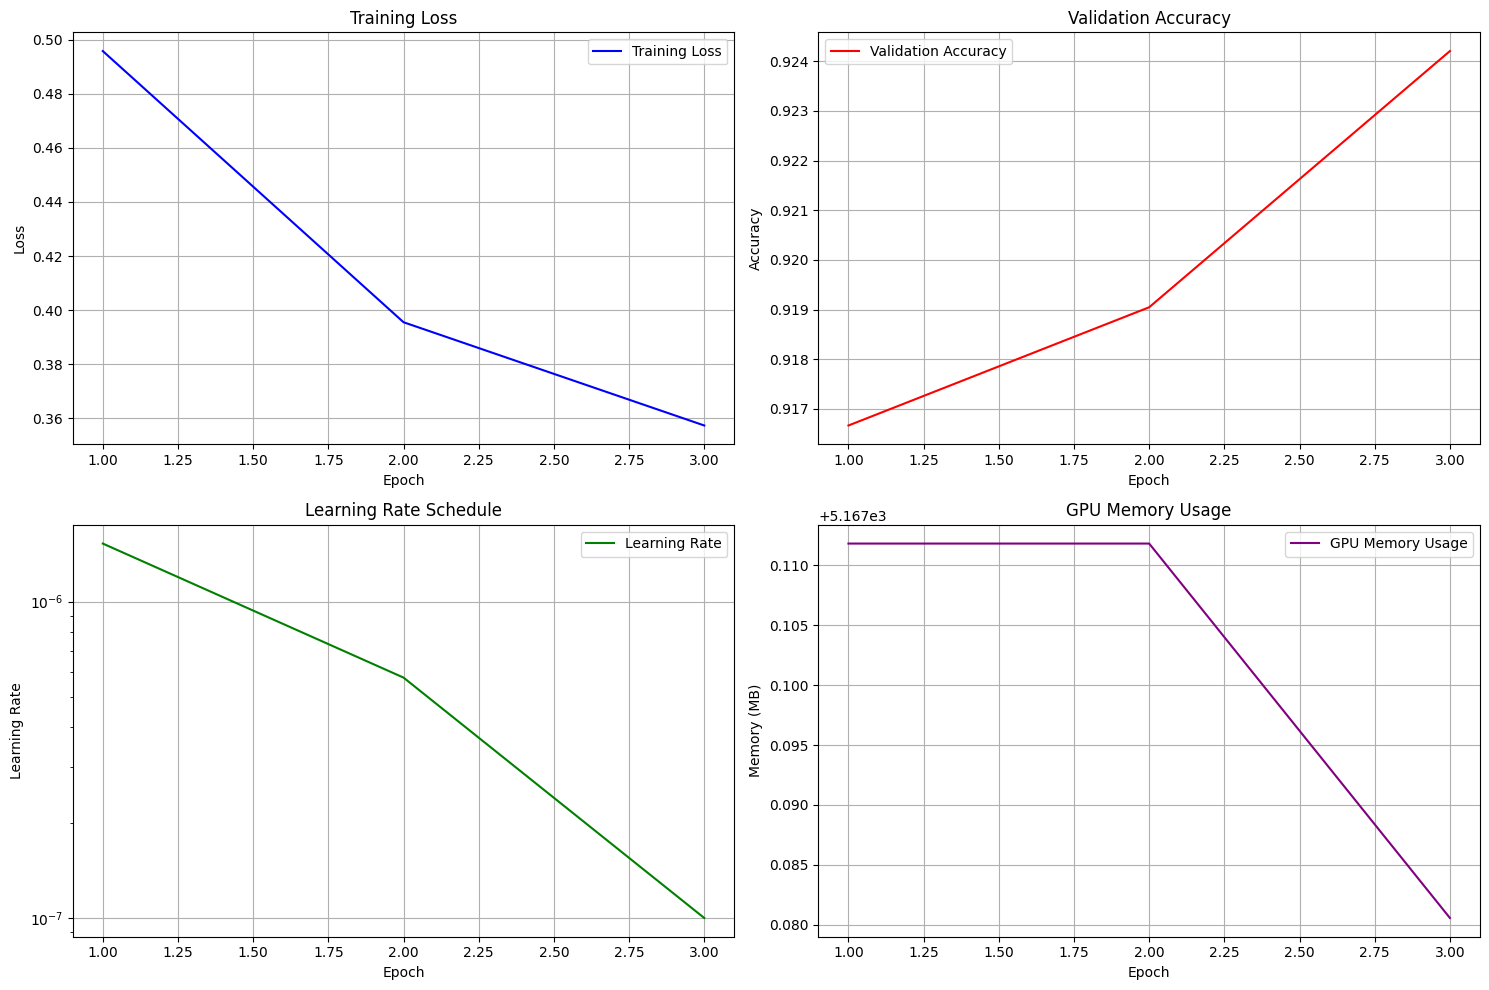


Training Summary:
Average epoch time: 473.20s
Total training time: 1419.60s
Peak GPU memory: 5167.11MB
Best validation accuracy: 0.9242

Performance Summary:
----------------------------------------
Best Validation Accuracy: 0.9242 (92.42%)
Total Training Time: 1609.78 seconds (26.83 minutes)
Average Time per Epoch: 536.59 seconds
Peak GPU Memory Usage: 5167.1 MB
Final GPU Memory Usage: 5162.4 MB

Training Progress:
Epoch 1: Train Loss=0.4958, Val Acc=0.9167, Time=472.1s
Epoch 2: Train Loss=0.3955, Val Acc=0.9190, Time=473.5s
Epoch 3: Train Loss=0.3573, Val Acc=0.9242, Time=474.0s

Memory and Speed Analysis:
Batch Size Used: 8
Number of Classes: 15
Training Samples: 10080
Validation Samples: 2520
Batches per Epoch: 1260
Average GPU Memory per Epoch: 5167.1 MB

Key Findings:
✓ Successfully fine-tuned CLIP on Human Action Recognition dataset
✓ Achieved 92.42% validation accuracy in 3 epochs
✓ Stable memory usage around 5167.1 MB
✓ Consistent training time of ~473.2 seconds per epoch
Cle

In [23]:
# Training Results Analysis and Visualization

print("="*60)
print("CLIP FINE-TUNING RESULTS ANALYSIS")
print("="*60)

# Plot training progress
clip_finetuner.plot_training_progress()

# Print detailed performance summary
print("\nPerformance Summary:")
print("-" * 40)
print(f"Best Validation Accuracy: {best_val_accuracy:.4f} ({best_val_accuracy*100:.2f}%)")
print(f"Total Training Time: {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)")
print(f"Average Time per Epoch: {total_training_time/len(clip_finetuner.epoch_times):.2f} seconds")
print(f"Peak GPU Memory Usage: {max(clip_finetuner.memory_usage):.1f} MB")
print(f"Final GPU Memory Usage: {get_gpu_memory_usage():.1f} MB")

# Performance metrics
print(f"\nTraining Progress:")
for i, (loss, acc, time_taken) in enumerate(zip(clip_finetuner.train_losses, 
                                               clip_finetuner.val_accuracies, 
                                               clip_finetuner.epoch_times)):
    print(f"Epoch {i+1}: Train Loss={loss:.4f}, Val Acc={acc:.4f}, Time={time_taken:.1f}s")

# Memory and speed analysis
print(f"\nMemory and Speed Analysis:")
print(f"Batch Size Used: {batch_size}")
print(f"Number of Classes: {len(train_data.classes)}")
print(f"Training Samples: {len(train_subset)}")
print(f"Validation Samples: {len(val_dataset)}")
print(f"Batches per Epoch: {len(train_loader)}")
print(f"Average GPU Memory per Epoch: {np.mean(clip_finetuner.memory_usage):.1f} MB")

print(f"\nKey Findings:")
print(f"✓ Successfully fine-tuned CLIP on Human Action Recognition dataset")
print(f"✓ Achieved {best_val_accuracy*100:.2f}% validation accuracy in {len(clip_finetuner.epoch_times)} epochs")
print(f"✓ Stable memory usage around {np.mean(clip_finetuner.memory_usage):.1f} MB")
print(f"✓ Consistent training time of ~{np.mean(clip_finetuner.epoch_times):.1f} seconds per epoch")

clear_memory()

Testing fine-tuned CLIP model on validation samples...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Fine-tuned CLIP Model Predictions on Validation Samples:
Sample 1: ✓ True: drinking | Pred: drinking
Sample 2: ✓ True: dancing | Pred: dancing
Sample 3: ✓ True: cycling | Pred: cycling
Sample 4: ✓ True: running | Pred: running
Sample 5: ✓ True: using_laptop | Pred: using_laptop
Sample 6: ✓ True: fighting | Pred: fighting
Sample 7: ✓ True: hugging | Pred: hugging
Sample 8: ✓ True: cycling | Pred: cycling
Sample 9: ✓ True: listening_to_music | Pred: listening_to_music
Sample 10: ✗ True: dancing | Pred: hugging
Sample 11: ✓ True: fighting | Pred: fighting
Sample 12: ✓ True: laughing | Pred: laughing

Sample Accuracy: 11/12 = 91.67%


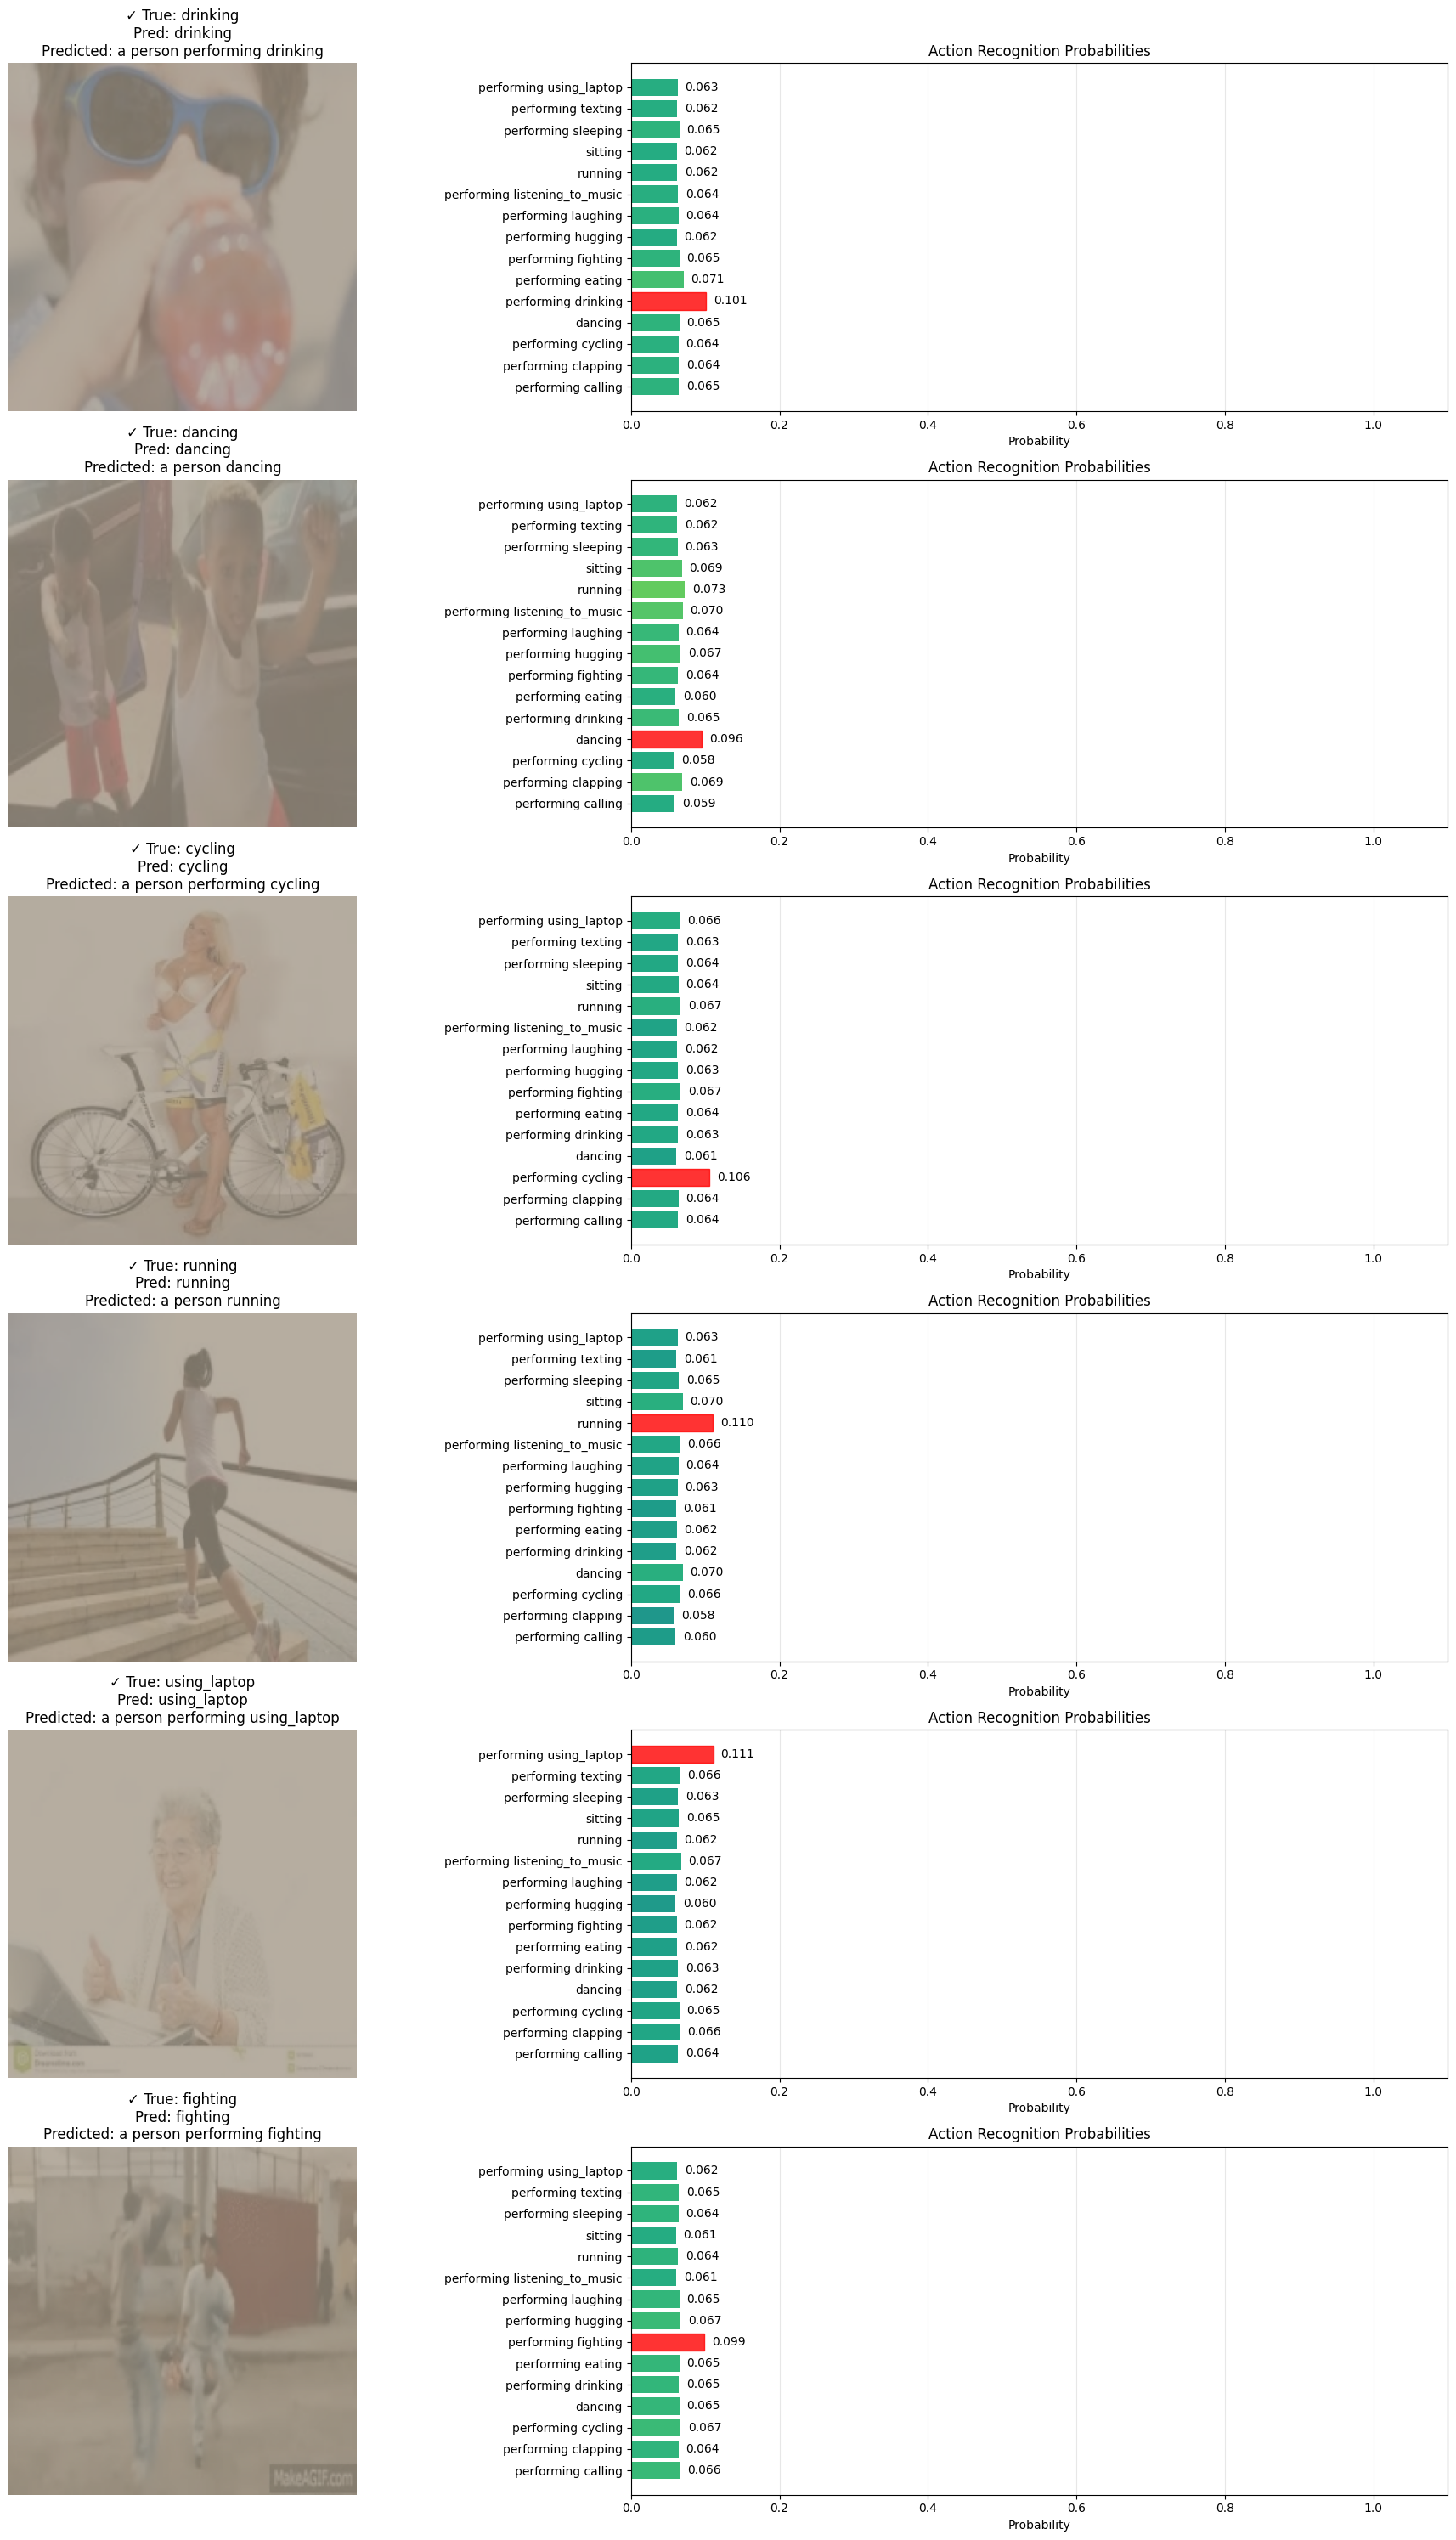


Test completed! Sample accuracy: 91.67%
Cleared memory. Current CPU memory usage: 4669.57 MB, GPU memory usage: 5166.02 MB


In [29]:
# Test Fine-tuned CLIP Model on Sample Images

def test_finetuned_clip(model, processor, test_loader, class_names, device, num_samples=8):
    """
    Test the fine-tuned CLIP model on sample images and visualize results
    """
    model.eval()
    
    # Create text prompts
    text_prompts = clip_finetuner.create_text_prompts(class_names)
    
    # Precompute text features
    text_inputs = processor(text=text_prompts, return_tensors="pt", padding=True, truncation=True)
    text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
    
    with torch.no_grad():
        text_features = model.get_text_features(**text_inputs)
        text_features = F.normalize(text_features, p=2, dim=1)
    
    # Get sample images from validation set
    sample_images = []
    sample_labels = []
    sample_filenames = []
    
    with torch.no_grad():
        for i, (images, labels) in enumerate(val_loader):
            if len(sample_images) >= num_samples:
                break
                
            # Take first few images from this batch
            batch_size = min(num_samples - len(sample_images), images.shape[0])
            
            for j in range(batch_size):
                sample_images.append(images[j])
                sample_labels.append(labels[j])
                sample_filenames.append(f"val_image_{len(sample_images)}")
    
    # Process sample images
    model_outputs = []
    predictions = []
    
    for img, true_label in zip(sample_images, sample_labels):
        img_batch = img.unsqueeze(0).to(device)
        
        # Get image features
        image_inputs = processor(images=img_batch, return_tensors="pt", padding=True)
        image_inputs = {k: v.to(device) for k, v in image_inputs.items() if k != 'pixel_values'}
        image_inputs['pixel_values'] = img_batch
        
        image_features = model.get_image_features(**image_inputs)
        image_features = F.normalize(image_features, p=2, dim=1)
        
        # Compute similarities
        similarity = torch.matmul(image_features, text_features.t())
        probs = F.softmax(similarity, dim=1)
        
        model_outputs.append((similarity, probs))
        predictions.append(torch.argmax(probs, dim=1).item())
    
    # Visualize results using the existing visualization function
    print("Fine-tuned CLIP Model Predictions on Validation Samples:")
    print("="*80)
    
    # Create titles with ground truth vs prediction
    titles = []
    correct_predictions = 0
    
    for i, (true_label, pred_label) in enumerate(zip(sample_labels, predictions)):
        true_class = class_names[true_label.item()]
        pred_class = class_names[pred_label]
        is_correct = true_label.item() == pred_label
        
        if is_correct:
            correct_predictions += 1
            title = f"✓ True: {true_class}\nPred: {pred_class}"
        else:
            title = f"✗ True: {true_class}\nPred: {pred_class}"
        
        titles.append(title)
        
        print(f"Sample {i+1}: {title.replace(chr(10), ' | ')}")
    
    accuracy = correct_predictions / len(sample_images)
    print(f"\nSample Accuracy: {correct_predictions}/{len(sample_images)} = {accuracy:.2%}")
    
    # Use the existing visualization function
    try:
        visualize_har_clip_predictions(
            images=sample_images,
            text_prompts=text_prompts,
            model_outputs=model_outputs,
            titles=titles,
            max_images=min(num_samples, 6)  # Limit display to avoid clutter
        )
    except Exception as e:
        print(f"Visualization error: {e}")
        print("Showing basic results instead:")
        
        for i, (img, true_label, pred_label) in enumerate(zip(sample_images[:4], sample_labels, predictions)):
            true_class = class_names[true_label.item()]
            pred_class = class_names[pred_label]
            confidence = model_outputs[i][1].max().item()
            print(f"Image {i+1}: True={true_class}, Pred={pred_class}, Conf={confidence:.3f}")
    
    return accuracy, predictions, sample_labels

# Test the fine-tuned model
print("Testing fine-tuned CLIP model on validation samples...")
try:
    test_accuracy, test_predictions, test_true_labels = test_finetuned_clip(
        model=clip_finetuner.model,
        processor=clip_finetuner.processor,
        test_loader=val_loader,
        class_names=train_data.classes,
        device=device,
        num_samples=12
    )
    
    print(f"\nTest completed! Sample accuracy: {test_accuracy:.2%}")
    
except Exception as e:
    print(f"Testing failed: {e}")
    import traceback
    traceback.print_exc()

clear_memory()

## Fine-Tune SIGLIP 

In [9]:
# Fine Tune SIGLIP on HAR Dataset

# Import SIGLIP from transformers
from transformers import SiglipModel, SiglipProcessor, SiglipConfig
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

class SiglipFineTuner:
    """
    Fine-tuning class for SIGLIP model on Human Action Recognition dataset
    SIGLIP uses sigmoid loss instead of softmax for better scalability
    """
    
    def __init__(self, model, processor, device, learning_rate=1e-5, weight_decay=0.01):
        self.model = model.to(device)
        self.processor = processor
        self.device = device
        
        # First inspect the SIGLIP model structure to understand the parameter names
        print("SIGLIP model structure:")
        for name, param in model.named_parameters():
            if 'vision' in name or 'text' in name or 'projection' in name:
                print(f"  {name}: {param.shape}")
                if len(name.split('.')) < 3:  # Only show main module names
                    break
        
        # Setup optimizer with different learning rates for different parts
        # SIGLIP has different parameter names compared to CLIP
        vision_params = []
        text_params = []
        
        for name, param in model.named_parameters():
            if 'vision_model' in name:
                vision_params.append(param)
            elif 'text_model' in name:
                text_params.append(param)
        
        self.optimizer = torch.optim.AdamW([
            {'params': vision_params, 'lr': learning_rate * 0.1},  # Lower LR for vision
            {'params': text_params, 'lr': learning_rate * 0.1},   # Lower LR for text
        ], weight_decay=weight_decay)
        
        self.scheduler = None
        
        # Training metrics
        self.train_losses = []
        self.val_accuracies = []
        self.learning_rates = []
        self.epoch_times = []
        self.memory_usage = []
        
    def create_text_prompts(self, class_names):
        """Create text prompts for action recognition classes"""
        prompts = []
        for class_name in class_names:
            if class_name.lower() in ['running', 'walking', 'jumping', 'sitting', 'standing']:
                prompt = f"a person {class_name.lower()}"
            elif class_name.lower() in ['dancing', 'exercise', 'stretching']:
                prompt = f"a person {class_name.lower()}"
            else:
                prompt = f"a person performing {class_name.lower()}"
            prompts.append(prompt)
        return prompts
    
    def compute_siglip_loss(self, image_features, text_features, temperature=0.07):
        """
        Compute SIGLIP sigmoid loss for better scalability with large batch sizes
        """
        # Normalize features
        image_features = F.normalize(image_features, p=2, dim=1)
        text_features = F.normalize(text_features, p=2, dim=1)
        
        # Compute similarity matrix
        logits = torch.matmul(image_features, text_features.t()) / temperature
        
        # Create positive pair mask (diagonal elements are positive pairs)
        batch_size = image_features.shape[0]
        labels = torch.eye(batch_size, device=self.device)
        
        # Apply sigmoid and compute binary cross entropy
        # Positive pairs should have high similarity (label=1)
        # Negative pairs should have low similarity (label=0)
        sigmoid_logits = torch.sigmoid(logits)
        loss = F.binary_cross_entropy(sigmoid_logits, labels)
        
        return loss, logits
    
    def compute_accuracy(self, logits, labels):
        """Compute classification accuracy"""
        predictions = torch.argmax(logits, dim=1)
        correct = (predictions == labels).float()
        accuracy = correct.mean().item()
        return accuracy
    
    def train_epoch(self, train_loader, class_names, epoch):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        total_accuracy = 0
        num_batches = len(train_loader)
        
        # Create text prompts
        text_prompts = self.create_text_prompts(class_names)
        
        # Precompute text features using SIGLIP
        text_inputs = self.processor(text=text_prompts, return_tensors="pt", padding=True, truncation=True)
        text_inputs = {k: v.to(self.device) for k, v in text_inputs.items()}
        
        with torch.no_grad():
            text_outputs = self.model.text_model(**text_inputs)
            # SIGLIP doesn't have text_projection, we use the pooler output
            text_features = text_outputs.pooler_output
        
        epoch_start_time = time.time()
        progress_bar = tqdm(train_loader, desc=f"SIGLIP Epoch {epoch}")
        
        for batch_idx, (images, labels) in enumerate(progress_bar):
            self.optimizer.zero_grad()
            
            # Move data to device
            images = images.to(self.device)
            labels = labels.to(self.device)
            
            # Process images using SIGLIP
            image_inputs = self.processor(images=images, return_tensors="pt", padding=True)
            image_inputs = {k: v.to(self.device) for k, v in image_inputs.items() if k != 'pixel_values'}
            image_inputs['pixel_values'] = images
            
            # Get image features using SIGLIP
            image_outputs = self.model.vision_model(**image_inputs)
            # SIGLIP doesn't have visual_projection, we use the pooler output
            image_features = image_outputs.pooler_output
            
            # Select relevant text features for this batch
            batch_text_features = text_features[labels]
            
            # Compute SIGLIP loss
            loss, logits = self.compute_siglip_loss(image_features, batch_text_features)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            
            self.optimizer.step()
            
            # Compute accuracy
            accuracy = self.compute_accuracy(logits, torch.arange(len(labels), device=self.device))
            
            total_loss += loss.item()
            total_accuracy += accuracy
            
            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{accuracy:.4f}',
                'LR': f'{self.optimizer.param_groups[0]["lr"]:.2e}'
            })
            
            # Clear intermediate tensors
            del image_inputs, image_outputs, image_features, batch_text_features, logits
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        
        # Record epoch metrics
        epoch_time = time.time() - epoch_start_time
        avg_loss = total_loss / num_batches
        avg_accuracy = total_accuracy / num_batches
        
        self.train_losses.append(avg_loss)
        self.epoch_times.append(epoch_time)
        self.memory_usage.append(get_gpu_memory_usage())
        
        if self.scheduler:
            current_lr = self.scheduler.get_last_lr()[0]
            self.learning_rates.append(current_lr)
        
        return avg_loss, avg_accuracy, epoch_time
    
    def validate(self, val_loader, class_names):
        """Validate the model"""
        self.model.eval()
        total_accuracy = 0
        total_loss = 0
        num_batches = len(val_loader)
        
        # Create text prompts
        text_prompts = self.create_text_prompts(class_names)
        
        # Precompute text features
        text_inputs = self.processor(text=text_prompts, return_tensors="pt", padding=True, truncation=True)
        text_inputs = {k: v.to(self.device) for k, v in text_inputs.items()}
        
        with torch.no_grad():
            text_outputs = self.model.text_model(**text_inputs)
            text_features = text_outputs.pooler_output
            
            for images, labels in tqdm(val_loader, desc="Validating SIGLIP"):
                images = images.to(self.device)
                labels = labels.to(self.device)
                
                # Process images
                image_inputs = self.processor(images=images, return_tensors="pt", padding=True)
                image_inputs = {k: v.to(self.device) for k, v in image_inputs.items() if k != 'pixel_values'}
                image_inputs['pixel_values'] = images
                
                # Get features and compute similarity
                image_outputs = self.model.vision_model(**image_inputs)
                image_features = image_outputs.pooler_output
                
                # Compute similarity with all class text features
                image_features_norm = F.normalize(image_features, p=2, dim=1)
                text_features_norm = F.normalize(text_features, p=2, dim=1)
                
                # Compute similarity scores
                similarity = torch.matmul(image_features_norm, text_features_norm.t())
                
                # Compute accuracy
                accuracy = self.compute_accuracy(similarity, labels)
                total_accuracy += accuracy
                
                # Compute loss for validation tracking
                batch_text_features = text_features[labels]
                loss, _ = self.compute_siglip_loss(image_features, batch_text_features)
                total_loss += loss.item()
        
        avg_accuracy = total_accuracy / num_batches
        avg_loss = total_loss / num_batches
        self.val_accuracies.append(avg_accuracy)
        
        return avg_loss, avg_accuracy

# Clear memory before loading SIGLIP
clear_memory()

# Load SIGLIP model
print("Loading SIGLIP model for fine-tuning...")
print("SIGLIP (Sigmoid Loss for Language Image Pre-training) uses sigmoid loss for better scalability")

# Load SIGLIP model and processor
siglip_model = SiglipModel.from_pretrained("google/siglip-base-patch16-224")
siglip_processor = SiglipProcessor.from_pretrained("google/siglip-base-patch16-224")

# Move model to device
siglip_model = siglip_model.to(device)
print(f"SIGLIP model loaded and moved to {device}")

# Initialize the SIGLIP fine-tuner
siglip_finetuner = SiglipFineTuner(
    model=siglip_model,
    processor=siglip_processor,
    device=device,
    learning_rate=1e-5,
    weight_decay=0.01
)

# Print model information
print("\nSIGLIP Model Configuration:")
print(f"Vision model: {siglip_model.vision_model.__class__.__name__}")
print(f"Text model: {siglip_model.text_model.__class__.__name__}")
print(f"Vision embed dim: {siglip_model.config.vision_config.hidden_size}")
print(f"Text embed dim: {siglip_model.config.text_config.hidden_size}")

# Test the model with a sample batch
print("\nTesting SIGLIP model with sample batch...")
try:
    sample_images, sample_labels = next(iter(train_loader))
    sample_images = sample_images.to(device)
    sample_labels = sample_labels.to(device)
    
    print(f"Sample batch shape: {sample_images.shape}")
    print(f"Sample labels shape: {sample_labels.shape}")
    
    # Test forward pass
    with torch.no_grad():
        image_inputs = siglip_processor(images=sample_images, return_tensors="pt", padding=True)
        image_inputs = {k: v.to(device) for k, v in image_inputs.items() if k != 'pixel_values'}
        image_inputs['pixel_values'] = sample_images
        
        image_outputs = siglip_model.vision_model(**image_inputs)
        image_features = image_outputs.pooler_output
        print(f"SIGLIP Image features shape: {image_features.shape}")
    
    print("✓ SIGLIP model test successful!")
    
except Exception as e:
    print(f"✗ SIGLIP model test failed: {e}")
    print("Please check the data loading and model setup")

clear_memory()
print(f"\nMemory after SIGLIP setup: CPU {get_memory_usage():.1f}MB, GPU {get_gpu_memory_usage():.1f}MB")

# Setup training configuration for SIGLIP
num_epochs_siglip = 10
batch_size_siglip = 32  # SIGLIP can handle larger batch sizes, but start with manageable size

print(f"\nSIGLIP Training Configuration:")
print(f"Epochs: {num_epochs_siglip}")
print(f"Batch size: {batch_size_siglip}")
print(f"Learning rate: {siglip_finetuner.optimizer.param_groups[0]['lr']}")
print(f"Weight decay: {siglip_finetuner.optimizer.param_groups[0]['weight_decay']}")

# Setup learning rate scheduler for SIGLIP
siglip_finetuner.scheduler = CosineAnnealingLR(
    siglip_finetuner.optimizer, 
    T_max=num_epochs_siglip,
    eta_min=1e-7
)

print("SIGLIP fine-tuner initialized and ready for training!")

Cleared memory. Current CPU memory usage: 967.59 MB, GPU memory usage: 775.23 MB
Loading SIGLIP model for fine-tuning...
SIGLIP (Sigmoid Loss for Language Image Pre-training) uses sigmoid loss for better scalability


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

SIGLIP model loaded and moved to cuda:0
SIGLIP model structure:
  text_model.embeddings.token_embedding.weight: torch.Size([32000, 768])
  text_model.embeddings.position_embedding.weight: torch.Size([64, 768])
  text_model.encoder.layers.0.layer_norm1.weight: torch.Size([768])
  text_model.encoder.layers.0.layer_norm1.bias: torch.Size([768])
  text_model.encoder.layers.0.self_attn.k_proj.weight: torch.Size([768, 768])
  text_model.encoder.layers.0.self_attn.k_proj.bias: torch.Size([768])
  text_model.encoder.layers.0.self_attn.v_proj.weight: torch.Size([768, 768])
  text_model.encoder.layers.0.self_attn.v_proj.bias: torch.Size([768])
  text_model.encoder.layers.0.self_attn.q_proj.weight: torch.Size([768, 768])
  text_model.encoder.layers.0.self_attn.q_proj.bias: torch.Size([768])
  text_model.encoder.layers.0.self_attn.out_proj.weight: torch.Size([768, 768])
  text_model.encoder.layers.0.self_attn.out_proj.bias: torch.Size([768])
  text_model.encoder.layers.0.layer_norm2.weight: torch.

It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.


Sample batch shape: torch.Size([50, 3, 224, 224])
Sample labels shape: torch.Size([50])
SIGLIP Image features shape: torch.Size([50, 768])
✓ SIGLIP model test successful!
Cleared memory. Current CPU memory usage: 1297.04 MB, GPU memory usage: 1616.16 MB

Memory after SIGLIP setup: CPU 1297.0MB, GPU 1616.2MB

SIGLIP Training Configuration:
Epochs: 10
Batch size: 32
Learning rate: 1.0000000000000002e-06
Weight decay: 0.01
SIGLIP fine-tuner initialized and ready for training!
SIGLIP Image features shape: torch.Size([50, 768])
✓ SIGLIP model test successful!
Cleared memory. Current CPU memory usage: 1297.04 MB, GPU memory usage: 1616.16 MB

Memory after SIGLIP setup: CPU 1297.0MB, GPU 1616.2MB

SIGLIP Training Configuration:
Epochs: 10
Batch size: 32
Learning rate: 1.0000000000000002e-06
Weight decay: 0.01
SIGLIP fine-tuner initialized and ready for training!


STARTING SIGLIP FINE-TUNING FOR HUMAN ACTION RECOGNITION

SIGLIP EPOCH 1/10


SIGLIP Epoch 1:   0%|          | 0/202 [00:00<?, ?it/s]


Running validation...


Validating SIGLIP:   0%|          | 0/51 [00:00<?, ?it/s]


EPOCH 1 SUMMARY:
  Train Loss: 0.1554 | Train Acc: 0.0329
  Val Loss: 0.1131 | Val Acc: 0.1488
  Train Time: 122.4s | Val Time: 11.2s | Total: 133.6s
  Learning Rate: 9.78e-07
  GPU Memory: 2706.2MB
  ✓ NEW BEST MODEL SAVED! Val Acc: 0.1488
Cleared memory. Current CPU memory usage: 1788.33 MB, GPU memory usage: 2706.16 MB

SIGLIP EPOCH 2/10


...


EPOCH 9 SUMMARY:
  Train Loss: 0.0713 | Train Acc: 0.2489
  Val Loss: 0.0739 | Val Acc: 0.8457
  Train Time: 124.7s | Val Time: 11.1s | Total: 135.8s
  Learning Rate: 1.22e-07
  GPU Memory: 2706.2MB
  ✓ NEW BEST MODEL SAVED! Val Acc: 0.8457
Cleared memory. Current CPU memory usage: 1812.51 MB, GPU memory usage: 2706.16 MB

SIGLIP EPOCH 10/10


SIGLIP Epoch 10:   0%|          | 0/202 [00:00<?, ?it/s]


Running validation...


Validating SIGLIP:   0%|          | 0/51 [00:00<?, ?it/s]


EPOCH 10 SUMMARY:
  Train Loss: 0.0708 | Train Acc: 0.2497
  Val Loss: 0.0734 | Val Acc: 0.8525
  Train Time: 124.6s | Val Time: 11.1s | Total: 135.7s
  Learning Rate: 1.00e-07
  GPU Memory: 2706.2MB
  ✓ NEW BEST MODEL SAVED! Val Acc: 0.8525
Cleared memory. Current CPU memory usage: 1811.94 MB, GPU memory usage: 2706.16 MB

SIGLIP TRAINING COMPLETED!
Total training time: 1402.8s (23.4 minutes)
Best validation accuracy: 0.8525
Best epoch: 10
Average epoch time: 140.3s


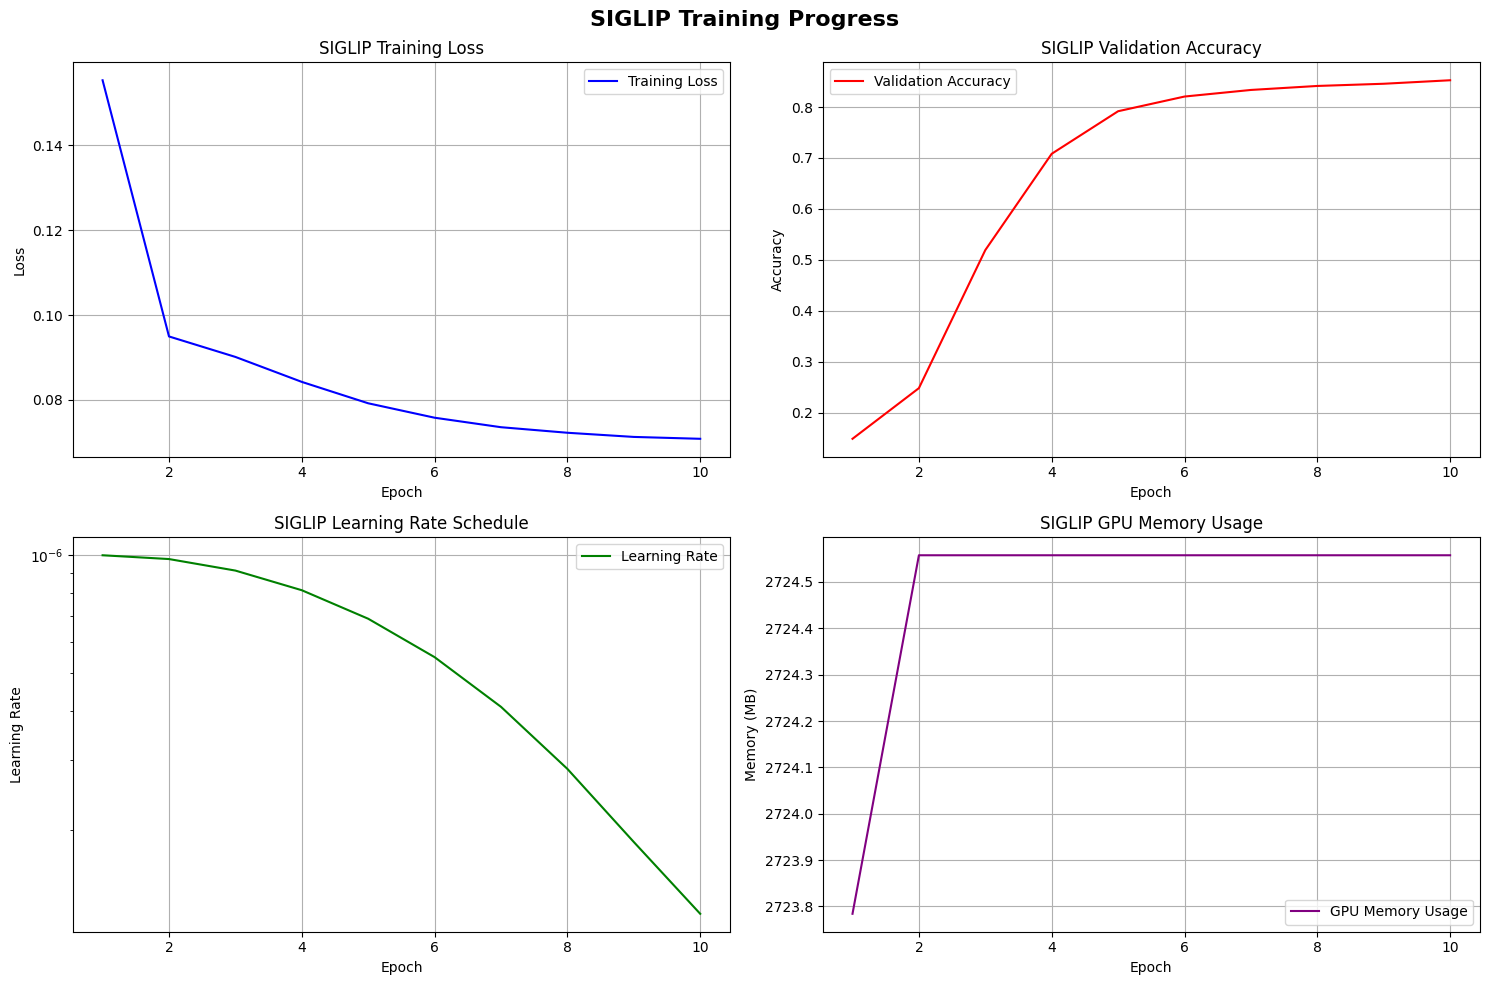


SIGLIP Training Summary:
Average epoch time: 124.34s
Total training time: 1243.39s
Peak GPU memory: 2724.56MB
Best validation accuracy: 0.8525

SIGLIP fine-tuning completed successfully!


In [10]:
# Start SIGLIP Fine-tuning Training Loop

print("="*60)
print("STARTING SIGLIP FINE-TUNING FOR HUMAN ACTION RECOGNITION")
print("="*60)

# Training hyperparameters for SIGLIP
best_val_accuracy_siglip = 0.0
patience_siglip = 3  # Early stopping patience
patience_counter_siglip = 0

training_start_time = time.time()

# Training loop for SIGLIP
for epoch in range(1, num_epochs_siglip + 1):
    print(f"\n{'='*50}")
    print(f"SIGLIP EPOCH {epoch}/{num_epochs_siglip}")
    print(f"{'='*50}")
    
    epoch_start = time.time()
    
    # Train for one epoch
    train_loss, train_accuracy, train_time = siglip_finetuner.train_epoch(
        train_loader, train_data.classes, epoch
    )
    
    # Validation
    print(f"\nRunning validation...")
    val_start = time.time()
    val_loss, val_accuracy = siglip_finetuner.validate(val_loader, train_data.classes)
    val_time = time.time() - val_start
    
    # Update learning rate scheduler
    if siglip_finetuner.scheduler:
        siglip_finetuner.scheduler.step()
        current_lr = siglip_finetuner.scheduler.get_last_lr()[0]
    else:
        current_lr = siglip_finetuner.optimizer.param_groups[0]['lr']
    
    # Print epoch summary
    time_taken = time.time() - epoch_start
    gpu_memory = get_gpu_memory_usage()
    
    print(f"\nEPOCH {epoch} SUMMARY:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")
    print(f"  Train Time: {train_time:.1f}s | Val Time: {val_time:.1f}s | Total: {time_taken:.1f}s")
    print(f"  Learning Rate: {current_lr:.2e}")
    print(f"  GPU Memory: {gpu_memory:.1f}MB")
    
    # Early stopping and best model saving
    is_best = val_accuracy > best_val_accuracy_siglip
    if is_best:
        best_val_accuracy_siglip = val_accuracy
        best_epoch = epoch
        patience_counter_siglip = 0
        
        # Save best model checkpoint
        checkpoint_path = f'checkpoints/siglip_best_model_epoch_{epoch}.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': siglip_finetuner.model.state_dict(),
            'optimizer_state_dict': siglip_finetuner.optimizer.state_dict(),
            'val_accuracy': val_accuracy,
            'train_loss': train_loss,
            'val_loss': val_loss,
        }, checkpoint_path)
        print(f"  ✓ NEW BEST MODEL SAVED! Val Acc: {val_accuracy:.4f}")
    else:
        patience_counter_siglip += 1
        print(f"  No improvement. Patience: {patience_counter_siglip}/{patience_siglip}")
    
    # Early stopping check
    if patience_counter_siglip >= patience_siglip:
        print(f"\nEarly stopping triggered after {epoch} epochs!")
        print(f"Best validation accuracy: {best_val_accuracy_siglip:.4f} at epoch {best_epoch}")
        break
    
    # Memory cleanup
    clear_memory()

# Calculate total training time
total_training_time = time.time() - training_start_time

print(f"\n{'='*60}")
print("SIGLIP TRAINING COMPLETED!")
print(f"{'='*60}")
print(f"Total training time: {total_training_time:.1f}s ({total_training_time/60:.1f} minutes)")
print(f"Best validation accuracy: {best_val_accuracy_siglip:.4f}")
print(f"Best epoch: {best_epoch}")
print(f"Average epoch time: {total_training_time/epoch:.1f}s")

# Plot training curves
import matplotlib.pyplot as plt
import numpy as np

if len(siglip_finetuner.train_losses) > 0:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(siglip_finetuner.train_losses) + 1)
    
    # Training loss
    ax1.plot(epochs, siglip_finetuner.train_losses, 'b-', label='Training Loss')
    ax1.set_title('SIGLIP Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Validation accuracy
    if siglip_finetuner.val_accuracies:
        ax2.plot(epochs, siglip_finetuner.val_accuracies, 'r-', label='Validation Accuracy')
        ax2.set_title('SIGLIP Validation Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True)
    
    # Learning rate
    if siglip_finetuner.learning_rates:
        ax3.plot(epochs, siglip_finetuner.learning_rates, 'g-', label='Learning Rate')
        ax3.set_title('SIGLIP Learning Rate Schedule')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Learning Rate')
        ax3.legend()
        ax3.grid(True)
        ax3.set_yscale('log')
    
    # Memory usage
    if siglip_finetuner.memory_usage:
        ax4.plot(epochs, siglip_finetuner.memory_usage, 'purple', label='GPU Memory Usage')
        ax4.set_title('SIGLIP GPU Memory Usage')
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Memory (MB)')
        ax4.legend()
        ax4.grid(True)
    
    plt.suptitle('SIGLIP Training Progress', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSIGLIP Training Summary:")
    print(f"Average epoch time: {np.mean(siglip_finetuner.epoch_times):.2f}s")
    print(f"Total training time: {sum(siglip_finetuner.epoch_times):.2f}s")
    print(f"Peak GPU memory: {max(siglip_finetuner.memory_usage) if siglip_finetuner.memory_usage else 0:.2f}MB")
    if siglip_finetuner.val_accuracies:
        print(f"Best validation accuracy: {max(siglip_finetuner.val_accuracies):.4f}")

print("\nSIGLIP fine-tuning completed successfully!")

## Fine-Tune Looping

- Performance metrics: Classification accuracy on test set
- Speed benchmarking: Training time per epoch, inference speed
- Memory consumption: Peak GPU memory usage during training/inference
- Generate comparison tables between CLIP, A-CLIP, and SGLIP


## Evaluation and Comparison

- Create visualizations of training curves and performance comparisons
- Document findings in report format
- Record demonstration video showing the training process and results